## Multimodal RAG — Local Hugging Face Pipeline

**RAG design**: text summaries of text/image/table elements are embedded for retrieval; retrieved raw images + text are passed to a local multimodal generation model.

### Local components
| Area | Local implementation |
|---|---|
| Extraction | `unstructured` PDF partitioning + image/table extraction |
| Text summarization | Hugging Face causal LM via `transformers` |
| Image summarization | Hugging Face Qwen-VL via `transformers` |
| Embeddings | Hugging Face `sentence-transformers` |
| Vector DB | Local Qdrant Docker service |
| Retrieval | Dense retrieval + BM25 + local cross-encoder reranking |
| Generation | Local Hugging Face text or vision-language model |
| Evaluation | BERTScore, answer precision/recall, context recall, must/should claim recall, visual claim recall |


### 1. Configuration

All tuneable parameters live here. Change values in `setup.env` or override directly.

In [43]:
import os, warnings
from dotenv import load_dotenv

warnings.filterwarnings('ignore')
load_dotenv("../setup.env", override=True)

# Reuse the Hugging Face cache downloaded on Windows when this notebook runs
# inside WSL. The WSL virtualenv also installs this behavior at Python startup
# via install_wsl_hf_cache_hook.py, but this fallback helps with other kernels.
def _truthy_env(name: str, default: bool = False) -> bool:
    value = os.getenv(name)
    if value is None:
        return default
    return value.strip().lower() not in {"0", "false", "no", "off"}


def _running_in_wsl() -> bool:
    if os.getenv("WSL_DISTRO_NAME"):
        return True
    try:
        import platform
        return "microsoft" in platform.release().lower()
    except Exception:
        return False


def _configure_wsl_hf_cache() -> None:
    if not _running_in_wsl():
        return
    hf_home = os.getenv("WSL_WINDOWS_HF_HOME", "/mnt/c/Users/danie/.cache/huggingface")
    if not os.path.isdir(hf_home):
        print(f"  [warn] WSL Windows Hugging Face cache not found: {hf_home}")
        return
    force_cache = _truthy_env("MULTIRAG_FORCE_WSL_HF_CACHE", True)

    def set_cache_var(name: str, value: str) -> None:
        if force_cache or not os.getenv(name):
            os.environ[name] = value

    set_cache_var("HF_HOME", hf_home)
    set_cache_var("HF_HUB_CACHE", os.path.join(hf_home, "hub"))
    set_cache_var("HF_DATASETS_CACHE", os.path.join(hf_home, "datasets"))

    if _truthy_env("MULTIRAG_HF_OFFLINE", True) and not _truthy_env("MULTIRAG_HF_ALLOW_DOWNLOADS", False):
        os.environ.setdefault("HF_HUB_OFFLINE", "1")
        os.environ.setdefault("TRANSFORMERS_OFFLINE", "1")

    print(
        f"  Hugging Face cache: {os.environ['HF_HOME']} "
        f"(Windows cache mounted in WSL, offline={os.environ.get('HF_HUB_OFFLINE') == '1'})"
    )


_configure_wsl_hf_cache()


# ── Paths ────────────────────────────────────────────────────────────────────
OUTPUT_PATH = os.getenv("OUTPUT_PATH", "./content/")
FILE_PATH   = os.getenv("FILE_PATH", OUTPUT_PATH + "attention.pdf")

# ── Chunking ─────────────────────────────────────────────────────────────────
# CHUNKING_STRATEGY: "by_title" | "basic"
CHUNKING_STRATEGY = os.getenv("CHUNKING_STRATEGY", "by_title")
MAX_CHARACTERS = int(os.getenv("MAX_CHARACTERS", "3000"))
COMBINE_UNDER_N = int(os.getenv("COMBINE_UNDER_N", "500"))
NEW_AFTER_N = int(os.getenv("NEW_AFTER_N", "2000"))
TABLES_AS_IMAGES = os.getenv("TABLES_AS_IMAGES", "true").lower() == "true"

# ── Local Hugging Face model settings ────────────────────────────────────────
# Small/CPU-friendly summarizer. For better summaries use e.g. "Qwen/Qwen2.5-3B-Instruct".
TEXT_SUMMARY_MODEL = os.getenv("TEXT_SUMMARY_MODEL", "Qwen/Qwen2.5-1.5B-Instruct")

# Local vision-language model for image/table summarization.
# Correct Qwen2.5-VL checkpoints include 3B, 7B, 32B, 72B; there is no official 2B Qwen2.5-VL.
IMAGE_SUMMARY_MODEL = os.getenv("IMAGE_SUMMARY_MODEL", "Qwen/Qwen2.5-VL-3B-Instruct")
MAX_IMAGE_SUMMARIZATION_LIMIT = int(os.getenv("MAX_IMAGE_SUMMARIZATION_LIMIT", "999"))

# Final local generation model. Use a VLM if you want retrieved images in the final answer.
# For text-only generation, set e.g. "Qwen/Qwen2.5-3B-Instruct" and images will be summarized before use.
GENERATION_MODEL = os.getenv("GENERATION_MODEL", "Qwen/Qwen2.5-VL-3B-Instruct")

# Generation limits
TEXT_SUMMARY_MAX_NEW_TOKENS = int(os.getenv("TEXT_SUMMARY_MAX_NEW_TOKENS", "180"))
GENERATION_MAX_NEW_TOKENS = int(os.getenv("GENERATION_MAX_NEW_TOKENS", "512"))
HF_DEVICE_MAP = os.getenv("HF_DEVICE_MAP", "auto")
HF_TORCH_DTYPE = os.getenv("HF_TORCH_DTYPE", "auto")

# ── Embeddings ────────────────────────────────────────────────────────────────
EMBEDDING_MODEL = os.getenv("EMBEDDING_MODEL", "BAAI/bge-m3")
# EMBEDDING_MODEL = os.getenv("EMBEDDING_MODEL", "sentence-transformers/all-MiniLM-L6-v2")

# ── Retrieval ─────────────────────────────────────────────────────────────────
RETRIEVER_K = int(os.getenv("RETRIEVER_K",  "10"))
RERANKER_TOP_N = int(os.getenv("RERANKER_TOP_N", "5"))
RERANKER_MODEL = os.getenv("RERANKER_MODEL", "cross-encoder/ms-marco-MiniLM-L-6-v2")
ENABLE_BM25 = os.getenv("ENABLE_BM25",   "true").lower() == "true"
ENABLE_RERANKING = os.getenv("ENABLE_RERANKING", "true").lower() == "true"

# ── Qdrant (local Docker vector DB) ───────────────────────────────────────────
# Start with: docker run -d --name qdrant -p 6333:6333 -p 6334:6334 \
#     -v $(pwd)/qdrant_storage:/qdrant/storage qdrant/qdrant
QDRANT_URL = os.getenv("QDRANT_URL", "http://localhost:6333")
QDRANT_API_KEY = os.getenv("QDRANT_API_KEY", "")
QDRANT_COLLECTION = os.getenv("QDRANT_COLLECTION", "multirag_local_hf")
RESET_QDRANT_COLLECTION = os.getenv("RESET_QDRANT_COLLECTION", "false").lower() == "true"

# Client URL for Ollama generation. Keep this separate from OLLAMA_HOST:
# OLLAMA_HOST is a server bind address, while this must be a reachable client URL.
OLLAMA_BASE_URL = os.getenv("OLLAMA_BASE_URL", "")

print("Local configuration loaded.")
print(f"Chunking   : {CHUNKING_STRATEGY} | max={MAX_CHARACTERS} chars | tables_as_images={TABLES_AS_IMAGES}")
print(f"Text model : {TEXT_SUMMARY_MODEL}")
print(f"Image model: {IMAGE_SUMMARY_MODEL}")
print(f"Generator  : {GENERATION_MODEL}")
print(f"Embeddings : {EMBEDDING_MODEL}")
print(f"Reranker   : {RERANKER_MODEL} (enabled={ENABLE_RERANKING})")
print(f"Qdrant     : {QDRANT_URL} | collection={QDRANT_COLLECTION}")
if OLLAMA_BASE_URL:
    print(f"Ollama URL : {OLLAMA_BASE_URL}")


Local configuration loaded.
Chunking   : by_title | max=3000 chars | tables_as_images=True
Text model : Qwen/Qwen2.5-1.5B-Instruct
Image model: Qwen/Qwen2.5-VL-3B-Instruct
Generator  : mistral-nemo:latest
Embeddings : BAAI/bge-m3
Reranker   : cross-encoder/ms-marco-MiniLM-L-6-v2 (enabled=True)
Qdrant     : http://localhost:6333 | collection=multirag_local_hf


### 2. Data Extraction

PDF is partitioned with `unstructured`. Tables are extracted both as text **and** as images (controlled by `TABLES_AS_IMAGES`).  
Each extracted element carries typed metadata for reliable downstream dispatch.

> **Prerequisites:** `poppler` and `tesseract` must be installed and on `PATH`.


In [44]:
from unstructured.partition.pdf import partition_pdf
from unstructured.chunking.title import chunk_by_title
from unstructured.chunking.basic import chunk_elements
from dataclasses import dataclass, field
from typing import List, Optional
import base64

@dataclass
class ExtractedDoc:
    """Typed container for a document element."""
    content: str                  # text content (or base64 for images)
    doc_type: str                 # "text" | "image" | "table_image"
    page_number: Optional[int] = None
    source_file: str = ""
    metadata: dict = field(default_factory=dict)

def partition_and_chunk_pdf(file_path: str) -> List[ExtractedDoc]:
    """
    Extract and chunk a PDF.
    Returns a flat list of ExtractedDoc, one per chunk/image.
    Chunking strategy is controlled by CHUNKING_STRATEGY env variable.
    """
    extract_types = ["Image"]
    if TABLES_AS_IMAGES:
        extract_types.append("Table")

    print(f"Partitioning '{file_path}' (strategy={CHUNKING_STRATEGY}, tables_as_images={TABLES_AS_IMAGES})...")

    # hi_res strategy is required for table inference and image extraction
    raw_elements = partition_pdf(
        filename=file_path,
        infer_tables_structure=True,
        strategy="hi_res",
        extract_image_block_types=extract_types,
        extract_image_block_to_payload=True,
    )

    # ── Chunking ────────────────────────────────────────────────────────────
    if CHUNKING_STRATEGY == "by_title":
        chunks = chunk_by_title(
            raw_elements,
            max_characters=MAX_CHARACTERS,
            combine_text_under_n_chars=COMBINE_UNDER_N,
            new_after_n_chars=NEW_AFTER_N,
            include_orig_elements=True,
        )
    elif CHUNKING_STRATEGY == "basic":
        chunks = chunk_elements(
            raw_elements,
            max_characters=MAX_CHARACTERS,
            new_after_n_chars=NEW_AFTER_N,
        )
    else:
        raise ValueError(f"Unknown CHUNKING_STRATEGY: {CHUNKING_STRATEGY!r}. Use 'by_title' or 'basic'.")

    docs: List[ExtractedDoc] = []

    for chunk in chunks:
        chunk_dict  = chunk.to_dict()
        chunk_type  = chunk_dict.get("type", "")
        page        = chunk_dict.get("metadata", {}).get("page_number")
        orig_elems  = getattr(chunk.metadata, "orig_elements", []) or []

        if chunk_type == "CompositeElement":
            # ── Plain text chunk ─────────────────────────────────────────
            docs.append(ExtractedDoc(
                content     = chunk.text,
                doc_type    = "text",
                page_number = page,
                source_file = file_path,
                metadata    = {"chunk_type": chunk_type},
            ))
            # ── Images embedded in this chunk ────────────────────────────
            for el in orig_elems:
                el_type = str(type(el))
                if "Image" in el_type:
                    b64 = getattr(getattr(el, "metadata", None), "image_base64", None)
                    if b64:
                        docs.append(ExtractedDoc(
                            content     = b64,
                            doc_type    = "image",
                            page_number = getattr(el.metadata, "page_number", page),
                            source_file = file_path,
                            metadata    = {"parent_chunk_page": page},
                        ))

        elif chunk_type == "Table":
            if TABLES_AS_IMAGES:
                # Table extracted as image
                b64 = getattr(getattr(chunk, "metadata", None), "image_base64", None)
                if b64:
                    docs.append(ExtractedDoc(
                        content     = b64,
                        doc_type    = "table_image",
                        page_number = page,
                        source_file = file_path,
                        metadata    = {"table_text": chunk.text},
                    ))
                else:
                    # Fallback: no image payload, store as text
                    docs.append(ExtractedDoc(
                        content     = chunk.text,
                        doc_type    = "text",
                        page_number = page,
                        source_file = file_path,
                        metadata    = {"chunk_type": "Table_text_fallback"},
                    ))
            else:
                # Tables as plain text
                docs.append(ExtractedDoc(
                    content     = chunk.text,
                    doc_type    = "text",
                    page_number = page,
                    source_file = file_path,
                    metadata    = {"chunk_type": "Table"},
                ))

    text_count  = sum(1 for d in docs if d.doc_type == "text")
    image_count = sum(1 for d in docs if d.doc_type in ("image", "table_image"))
    print(f"Extraction complete: {text_count} text chunks, {image_count} visual elements.")
    return docs


In [45]:
extracted_docs = partition_and_chunk_pdf(FILE_PATH)

text_docs  = [d for d in extracted_docs if d.doc_type == "text"]
image_docs = [d for d in extracted_docs if d.doc_type in ("image", "table_image")]

print(f"Text docs : {len(text_docs)}")
print(f"Image docs: {len(image_docs)}")
print(f"\nFirst text chunk (preview):")
print(text_docs[0].content[:300])


Partitioning './content/attention.pdf' (strategy=by_title, tables_as_images=True)...
Extraction complete: 28 text chunks, 6 visual elements.
Text docs : 28
Image docs: 6

First text chunk (preview):
2023

1706.03762v7 [cs.CL] 2 Aug

arXiv

Provided proper attribution is provided, Google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works.

Attention Is All You Need

Ashish Vaswani* Google Brain avaswani@google.com

Noam Sh


#### Image Verification

Displaying first extracted image (type=image):


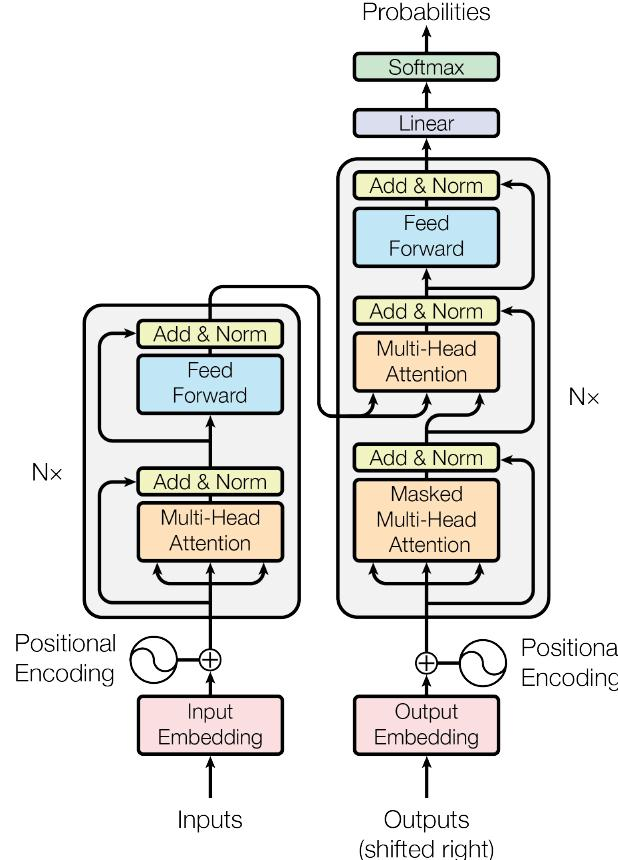

In [46]:
import base64
from IPython.display import Image as IPImage, display

def display_base64_image(b64_str: str) -> None:
    """Decode and display a base64-encoded image inline."""
    try:
        image_bytes = base64.b64decode(b64_str)
        display(IPImage(data=image_bytes))
    except Exception as e:
        print(f"[display_base64_image] Could not render image: {e}")

if image_docs:
    print(f"Displaying first extracted image (type={image_docs[0].doc_type}):")
    display_base64_image(image_docs[0].content)
else:
    print("No images extracted from this document.")


### 3. Local summarization

- **Text / Tables** → local Hugging Face causal LM set by `TEXT_SUMMARY_MODEL`.
- **Images** → local Hugging Face Qwen-VL model set by `IMAGE_SUMMARY_MODEL`.


In [47]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

TEXT_SUMMARY_PROMPT = """You are an assistant that produces concise, factual summaries of technical text and tables.
Output only the summary — no preamble, no commentary.

Text or table:
{element}"""

print(f"Loading local text summarization model: {TEXT_SUMMARY_MODEL} ...")
try:
    text_tokenizer = AutoTokenizer.from_pretrained(TEXT_SUMMARY_MODEL, trust_remote_code=True)
    text_model = AutoModelForCausalLM.from_pretrained(
        TEXT_SUMMARY_MODEL,
        torch_dtype=HF_TORCH_DTYPE,
        device_map=HF_DEVICE_MAP,
        trust_remote_code=True,
    )
    TEXT_SUMMARIZER_AVAILABLE = True
    print(f"  ✓ Text summarization ready: {TEXT_SUMMARY_MODEL}")
except Exception as e:
    print(f"  ✗ Could not load {TEXT_SUMMARY_MODEL}: {e}")
    print("    Text summarization will fall back to truncating source chunks.")
    text_tokenizer = text_model = None
    TEXT_SUMMARIZER_AVAILABLE = False


def local_text_generate(prompt: str, max_new_tokens: int = TEXT_SUMMARY_MAX_NEW_TOKENS) -> str:
    """Generate text locally with a Hugging Face instruct model."""
    if not TEXT_SUMMARIZER_AVAILABLE:
        return prompt[-1200:]

    messages = [{"role": "user", "content": prompt}]
    if hasattr(text_tokenizer, "apply_chat_template"):
        text = text_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    else:
        text = prompt

    inputs = text_tokenizer([text], return_tensors="pt").to(text_model.device)
    with torch.no_grad():
        generated = text_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=None,
            pad_token_id=text_tokenizer.eos_token_id,
        )
    new_tokens = generated[:, inputs.input_ids.shape[1]:]
    return text_tokenizer.batch_decode(new_tokens, skip_special_tokens=True)[0].strip()


class LocalTextSummaryChain:
    """Small compatibility wrapper replacing the previous LangChain/Groq chain."""
    def invoke(self, inp: dict) -> str:
        return local_text_generate(TEXT_SUMMARY_PROMPT.format(**inp), TEXT_SUMMARY_MAX_NEW_TOKENS)

    def batch(self, inputs: list, config: dict | None = None) -> list[str]:
        return [self.invoke(inp) for inp in inputs]


text_summary_chain = LocalTextSummaryChain()


Loading local text summarization model: Qwen/Qwen2.5-1.5B-Instruct ...
  ✗ Could not load Qwen/Qwen2.5-1.5B-Instruct: device disk is invalid
    Text summarization will fall back to truncating source chunks.


#### Summary cache (on-disk)

Summarization is the slowest step. The next cell defines `SummaryCache`, which stores summaries per source PDF + model on disk so subsequent runs skip already-summarized chunks.

Cache layout: one JSON file per `(source_file, file_content_hash, kind)` under `SUMMARY_CACHE_DIR` (default `./cache/summaries`). Entries inside are keyed by `sha256(model_name || content)`.

In [48]:
import hashlib
import json
from pathlib import Path
from typing import Dict, List, Tuple, Optional


class SummaryCache:
    """On-disk cache for chunk summaries."""

    def __init__(self, cache_dir: str = "./cache/summaries"):
        self.cache_dir = Path(cache_dir)
        self.cache_dir.mkdir(parents=True, exist_ok=True)

    @staticmethod
    def _content_key(content: str, model_name: str) -> str:
        h = hashlib.sha256()
        h.update(model_name.encode("utf-8")); h.update(b"||")
        h.update(content.encode("utf-8", errors="replace"))
        return h.hexdigest()

    @staticmethod
    def _file_fingerprint(file_path: str) -> str:
        p = Path(file_path)
        if not p.exists() or not p.is_file(): return "nofile"
        h = hashlib.sha256()
        with p.open("rb") as f:
            for ch in iter(lambda: f.read(1 << 20), b""): h.update(ch)
        return h.hexdigest()[:16]

    def _path_for(self, source_file: str, kind: str) -> Path:
        base = Path(source_file).name or "unknown"
        safe = "".join(c if c.isalnum() or c in "._-" else "_" for c in base)
        return self.cache_dir / f"{safe}__{self._file_fingerprint(source_file)}__{kind}.json"

    def _load(self, source_file: str, kind: str) -> Dict[str, str]:
        path = self._path_for(source_file, kind)
        if path.exists():
            try: return json.loads(path.read_text(encoding="utf-8"))
            except Exception as e:
                print(f"[SummaryCache] Could not read {path.name}: {e} — starting fresh.")
        return {}

    def _save(self, source_file: str, kind: str, data: Dict[str, str]) -> None:
        path = self._path_for(source_file, kind)
        tmp  = path.with_suffix(path.suffix + ".tmp")
        tmp.write_text(json.dumps(data, indent=2, ensure_ascii=False), encoding="utf-8")
        tmp.replace(path)

    def get_summaries(self, source_file, kind, contents, model_name):
        cache = self._load(source_file, kind)
        cached, missing = {}, []
        for i, content in enumerate(contents):
            key = self._content_key(content, model_name)
            if key in cache: cached[i] = cache[key]
            else:            missing.append(i)
        return cached, missing

    def store_summaries(self, source_file, kind, contents, summaries, model_name):
        if not contents: return
        cache = self._load(source_file, kind)
        for content, summary in zip(contents, summaries):
            cache[self._content_key(content, model_name)] = summary
        self._save(source_file, kind, cache)
        print(f"Cached {len(contents)} {kind} summaries → {self._path_for(source_file, kind).name}")


summary_cache = SummaryCache(os.getenv("SUMMARY_CACHE_DIR", "./cache/summaries"))
print(f"SummaryCache ready at: {summary_cache.cache_dir.resolve()}")


SummaryCache ready at: C:\Users\danie\Desktop\Multimodal-RAG\image_pipeline\cache\summaries


In [49]:
def summarize_texts(docs: List[ExtractedDoc], batch_size: int = 1) -> List[str]:
    """Cache-aware text summarization."""
    if not docs:
        return []
    source   = docs[0].source_file or "unknown"
    contents = [d.content for d in docs]
    cached, missing_idx = summary_cache.get_summaries(source, "text", contents, TEXT_SUMMARY_MODEL)
    summaries: List[Optional[str]] = [None] * len(docs)
    for i, s in cached.items(): summaries[i] = s
    if cached:
        print(f"  ✓ Loaded {len(cached)}/{len(docs)} text summaries from cache (source='{source}', model='{TEXT_SUMMARY_MODEL}').")
    if missing_idx:
        missing_contents = [contents[i] for i in missing_idx]
        inputs = [{"element": c} for c in missing_contents]
        print(f"Summarizing {len(inputs)} new text chunks with '{TEXT_SUMMARY_MODEL}'...")
        try:
            new_summaries = text_summary_chain.batch(inputs, {"max_concurrency": batch_size})
        except Exception as e:
            print(f"[summarize_texts] Batch failed ({e}). Falling back per-item.")
            new_summaries = []
            for inp in inputs:
                try:    new_summaries.append(text_summary_chain.invoke(inp))
                except Exception as e2:
                    print(f"  ✗ Failed on chunk: {e2}")
                    new_summaries.append(inp["element"][:300])
        for idx, s in zip(missing_idx, new_summaries):
            summaries[idx] = s
        summary_cache.store_summaries(source, "text", missing_contents, new_summaries, TEXT_SUMMARY_MODEL)
    else:
        print("  ✓ All text summaries served from cache (no LLM calls needed).")
    print(f"  ✓ {len(summaries)} text summaries ready.")
    return summaries  # type: ignore[return-value]


In [50]:
text_summaries = summarize_texts(text_docs)
print("\nSample summary:")
print(text_summaries[0])


  ✓ Loaded 28/28 text summaries from cache (source='./content/attention.pdf', model='Qwen/Qwen2.5-1.5B-Instruct').
  ✓ All text summaries served from cache (no LLM calls needed).
  ✓ 28 text summaries ready.

Sample summary:
**Summary:**

- **Title:** Attention Is All You Need
- **Authors:** Ashish Vaswani*, Noam Shazeer*, Niki Parmar*, Jakob Uszkoreit*, Llion Jones*, Aidan N. Gomez*, Lukasz Kaiser*
- **Publication Date:** August 2, 2023
- **Journal/Conference:** arXiv (CS.CL)
- **Attribution Required:** Proper attribution must be provided when reproducing tables and figures from this paper in journalistic or scholarly works.


In [51]:
import torch
from transformers import AutoProcessor

# ── Load the right Qwen-VL class based on IMAGE_SUMMARY_MODEL ────────────────
if "qwen2.5-vl" in IMAGE_SUMMARY_MODEL.lower():
    from transformers import Qwen2_5_VLForConditionalGeneration as _QwenVLModel
elif "qwen2-vl" in IMAGE_SUMMARY_MODEL.lower():
    from transformers import Qwen2VLForConditionalGeneration as _QwenVLModel
else:
    raise ValueError(
        f"IMAGE_SUMMARY_MODEL={IMAGE_SUMMARY_MODEL!r} is not a recognized Qwen-VL "
        "checkpoint. Use a 'Qwen/Qwen2.5-VL-*' or 'Qwen/Qwen2-VL-*' model."
    )

from qwen_vl_utils import process_vision_info

print(f"Loading vision model: {IMAGE_SUMMARY_MODEL} (class={_QwenVLModel.__name__}) ...")

try:
    qwen_model = _QwenVLModel.from_pretrained(
        IMAGE_SUMMARY_MODEL,
        torch_dtype       = "auto",
        device_map        = "auto",
        trust_remote_code = True,
    )
    qwen_processor = AutoProcessor.from_pretrained(IMAGE_SUMMARY_MODEL, trust_remote_code=True)
    QWEN_AVAILABLE = True
    print(f"  ✓ {IMAGE_SUMMARY_MODEL} ready.")
except Exception as e:
    print(f"  ✗ Could not load {IMAGE_SUMMARY_MODEL}: {e}")
    print("    Image summarization will use placeholder text.")
    qwen_model = qwen_processor = None
    QWEN_AVAILABLE = False


Loading vision model: Qwen/Qwen2.5-VL-3B-Instruct (class=Qwen2_5_VLForConditionalGeneration) ...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

  ✗ Could not load Qwen/Qwen2.5-VL-3B-Instruct: You are trying to offload the whole model to the disk. Please use the `disk_offload` function instead.
    Image summarization will use placeholder text.


In [52]:
def summarize_image_qwen(b64_str: str) -> str:
    """Summarize a single base64-encoded image using Qwen2.5-VL."""
    if not QWEN_AVAILABLE:
        return "[Image summarization unavailable — model not loaded]"

    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": f"data:image/jpeg;base64,{b64_str}"},
            {"type": "text",  "text":  "Identify and summarize the key information in this document element (image/table/chart). Be specific about structures, axes, values, and any visible text."},
        ],
    }]

    text_input   = qwen_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)

    inputs = qwen_processor(
        text   = [text_input],
        images = image_inputs,
        videos = video_inputs,
        padding     = True,
        return_tensors = "pt",
    ).to(qwen_model.device)

    generated_ids = qwen_model.generate(**inputs, max_new_tokens=300)
    trimmed = [out[len(inp):] for inp, out in zip(inputs.input_ids, generated_ids)]
    return qwen_processor.batch_decode(trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]


def summarize_images(docs: List[ExtractedDoc], limit: int = MAX_IMAGE_SUMMARIZATION_LIMIT) -> List[str]:
    """Cache-aware image summarization."""
    if not docs:
        return []
    source       = docs[0].source_file or "unknown"
    total        = min(len(docs), limit)
    contents     = [d.content for d in docs[:total]]
    cached, missing_idx = summary_cache.get_summaries(source, "image", contents, IMAGE_SUMMARY_MODEL)
    summaries: List[Optional[str]] = [None] * len(docs)
    for i, s in cached.items(): summaries[i] = s
    for i in range(total, len(docs)): summaries[i] = "[skipped — limit reached]"
    if cached:
        print(f"  ✓ Loaded {len(cached)}/{total} image summaries from cache (source='{source}', model='{IMAGE_SUMMARY_MODEL}').")
    if missing_idx:
        print(f"Summarizing {len(missing_idx)} new image(s) with '{IMAGE_SUMMARY_MODEL}'...")
        new_contents:  List[str] = []
        new_summaries: List[str] = []
        for idx in missing_idx:
            doc = docs[idx]
            try:
                s = summarize_image_qwen(doc.content)
                print(f"  [{idx+1}/{total}] ✓ type={doc.doc_type} page={doc.page_number}")
            except Exception as e:
                print(f"  [{idx+1}/{total}] ✗ Error on image: {e}")
                s = "[summarization error]"
            summaries[idx] = s
            if not s.startswith("["):
                new_contents.append(doc.content); new_summaries.append(s)
        if new_contents:
            summary_cache.store_summaries(source, "image", new_contents, new_summaries, IMAGE_SUMMARY_MODEL)
    else:
        print("  ✓ All image summaries served from cache (no vision-model calls needed).")
    success = sum(1 for s in summaries if s and not s.startswith("["))
    print(f"  Image summarization complete: {success}/{total} ready.")
    return summaries  # type: ignore[return-value]


In [53]:
image_summaries = summarize_images(image_docs)
if image_summaries:
    print("\nSample image summary:")
    print(image_summaries[0])


  ✓ Loaded 6/6 image summaries from cache (source='./content/attention.pdf', model='Qwen/Qwen2.5-VL-3B-Instruct').
  ✓ All image summaries served from cache (no vision-model calls needed).
  Image summarization complete: 6/6 ready.

Sample image summary:
The image depicts a neural network architecture, specifically a transformer model, which is commonly used for natural language processing tasks such as machine translation and text summarization. Here is a detailed summary of the key components and their functions:

1. **Input Embedding**: This layer takes raw input data and converts it into a sequence of embeddings. These embeddings capture the semantic meaning of the words.

2. **Positional Encoding**: This layer adds positional information to the embeddings. Positional encoding helps the model understand the order of elements in the sequence.

3. **Multi-Head Attention**: This layer allows the model to attend to different parts of the input sequence simultaneously. It consists of mu

In [54]:
RETRIEVER_K = 10
RERANKER_TOP_N = 5

print(RETRIEVER_K, RERANKER_TOP_N, ENABLE_BM25, ENABLE_RERANKING, RERANKER_MODEL)


10 5 True True cross-encoder/ms-marco-MiniLM-L-6-v2


### 4. Embeddings & Vector Store

Summaries are embedded locally with `EMBEDDING_MODEL` and stored in a **local Qdrant** instance running in Docker.  
`MultiVectorRetriever` maps each summary back to its typed `ExtractedDoc`.

**Start Qdrant once** (data persisted to `./qdrant_storage`):

```bash
docker run -d --name qdrant -p 6333:6333 -p 6334:6334 \
    -v $(pwd)/qdrant_storage:/qdrant/storage \
    qdrant/qdrant
```

REST dashboard: <http://localhost:6333/dashboard>. Install the Python client with `pip install langchain-qdrant qdrant-client`.

In [55]:
import uuid
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams
try:
    from langchain.retrievers.multi_vector import MultiVectorRetriever
except ImportError:
    from langchain_classic.retrievers.multi_vector import MultiVectorRetriever
from langchain_core.stores import InMemoryStore
from langchain_core.documents import Document

# ── Embedding model ──────────────────────────────────────────────────────────
print(f"Loading embedding model: {EMBEDDING_MODEL} ...")
embedding = HuggingFaceEmbeddings(
    model_name = EMBEDDING_MODEL,
    model_kwargs = {"trust_remote_code": True},
    encode_kwargs = {"normalize_embeddings": True},
)
EMBEDDING_DIM = len(embedding.embed_query("dimension probe"))
print(f"✓ Embedding model ready (dim={EMBEDDING_DIM}).")

# ── Local Qdrant vector store (Docker) ───────────────────────────────────────
client = QdrantClient(url=QDRANT_URL, api_key=QDRANT_API_KEY or None)

if RESET_QDRANT_COLLECTION and client.collection_exists(QDRANT_COLLECTION):
    client.delete_collection(QDRANT_COLLECTION)
    print(f"✓ Deleted existing Qdrant collection '{QDRANT_COLLECTION}'.")

if not client.collection_exists(QDRANT_COLLECTION):
    client.create_collection(
        collection_name = QDRANT_COLLECTION,
        vectors_config  = VectorParams(size=EMBEDDING_DIM, distance=Distance.COSINE),
    )
    print(f"✓ Created Qdrant collection '{QDRANT_COLLECTION}'.")
else:
    print(f"✓ Using existing Qdrant collection '{QDRANT_COLLECTION}'.")

vector_store = QdrantVectorStore(
    client = client,
    collection_name = QDRANT_COLLECTION,
    embedding = embedding,
)

docstore = InMemoryStore()
ID_KEY = "doc_id"

retriever = MultiVectorRetriever(
    vectorstore = vector_store,
    docstore = docstore,
    id_key = ID_KEY,
    search_kwargs = {"k": RETRIEVER_K},
)

print(f"Vector store and retriever ready (collection='{QDRANT_COLLECTION}', k={RETRIEVER_K}).")


Loading embedding model: BAAI/bge-m3 ...
✓ Embedding model ready (dim=1024).
✓ Using existing Qdrant collection 'multirag_local_hf'.
Vector store and retriever ready (collection='multirag_local_hf', k=10).


In [56]:
def index_documents(
    retriever,
    docs: List[ExtractedDoc],
    summaries: List[str],
    id_key: str = ID_KEY,
) -> List[str]:
    """
    Store summaries in the vector store and link them to their source ExtractedDocs.
    Each doc gets a UUID stored in both the vector store (as metadata) and the docstore.
    Returns the list of generated IDs.
    """
    if len(docs) != len(summaries):
        raise ValueError(
            f"Mismatch: {len(docs)} docs vs {len(summaries)} summaries. "
            "Each doc must have exactly one summary."
        )

    doc_ids: List[str] = []
    langchain_docs: List[Document] = []
    docstore_items: List[tuple] = []

    for doc, summary in zip(docs, summaries):
        if not summary or summary.startswith("["):
            # Skip placeholder summaries; they add noise to both dense and sparse indexes.
            continue
        uid = str(uuid.uuid4())
        doc_ids.append(uid)
        langchain_docs.append(Document(
            page_content = summary,
            metadata     = {
                id_key:      uid,
                "doc_type":  doc.doc_type,
                "page":      doc.page_number,
                "source":    doc.source_file,
            },
        ))
        docstore_items.append((uid, doc))

    try:
        if langchain_docs:
            retriever.vectorstore.add_documents(langchain_docs)
            # Store the exact original ExtractedDoc paired with each generated UUID.
            retriever.docstore.mset(docstore_items)
    except Exception as e:
        print(f"[index_documents] Indexing error: {e}")
        raise

    print(f"Indexed {len(langchain_docs)} documents (skipped {len(docs)-len(langchain_docs)} placeholders).")
    return doc_ids


In [57]:
print("Indexing text summaries...")
text_ids = index_documents(retriever, text_docs, text_summaries)

print("Indexing image summaries...")
image_ids = index_documents(retriever, image_docs, image_summaries)

print(f"\nTotal indexed: {len(text_ids)} text + {len(image_ids)} image = {len(text_ids)+len(image_ids)} documents.")


Indexing text summaries...
Indexed 28 documents (skipped 0 placeholders).
Indexing image summaries...
Indexed 6 documents (skipped 0 placeholders).

Total indexed: 28 text + 6 image = 34 documents.


### 5. Hybrid Retrieval + Reranking

**Hybrid search** combines dense vector similarity with sparse BM25 keyword matching.  
**Cross-encoder reranking** then re-scores the candidates with a dedicated relevance model.

Both are independently toggleable via `ENABLE_BM25` and `ENABLE_RERANKING`.


In [58]:
from rank_bm25 import BM25Okapi
from sentence_transformers import CrossEncoder
from langchain_core.documents import Document
from typing import List, Tuple
import numpy as np

# ── BM25 index ───────────────────────────────────────────────────────────────
class BM25Index:
    """Lightweight BM25 index over the indexed summaries."""
    def __init__(self):
        self._docs:    List[ExtractedDoc] = []
        self._texts:   List[str]          = []
        self._bm25                        = None

    def build(self, summaries: List[str], docs: List[ExtractedDoc]):
        """Build the index from summary strings and their corresponding ExtractedDocs."""
        self._texts  = summaries
        self._docs   = docs
        tokenized    = [t.lower().split() for t in summaries]
        self._bm25   = BM25Okapi(tokenized)
        print(f"BM25 index built on {len(summaries)} documents.")

    def retrieve(self, query: str, top_k: int = RETRIEVER_K) -> List[Tuple[float, ExtractedDoc]]:
        """Return (score, doc) pairs ranked by BM25 score."""
        if self._bm25 is None:
            return []
        scores   = self._bm25.get_scores(query.lower().split())
        top_idx  = np.argsort(scores)[::-1][:top_k]
        return [(float(scores[i]), self._docs[i]) for i in top_idx if scores[i] > 0]

bm25_index = BM25Index()

# Build BM25 over all summaries that were actually indexed (non-placeholder)
valid_text_pairs  = [(s, d) for s, d in zip(text_summaries,  text_docs)  if s and not s.startswith("[")]
valid_image_pairs = [(s, d) for s, d in zip(image_summaries, image_docs) if s and not s.startswith("[")]

all_summaries = [s for s, _ in valid_text_pairs + valid_image_pairs]
all_docs      = [d for _, d in valid_text_pairs + valid_image_pairs]

if ENABLE_BM25 and all_summaries:
    bm25_index.build(all_summaries, all_docs)
else:
    print("BM25 disabled (ENABLE_BM25=False).")


BM25 index built on 34 documents.


In [59]:
# ── Cross-encoder reranker ────────────────────────────────────────────────────
if ENABLE_RERANKING:
    print(f"Loading cross-encoder: {RERANKER_MODEL} ...")
    try:
        reranker = CrossEncoder(RERANKER_MODEL)
        RERANKER_AVAILABLE = True
        print(f"✓ Reranker ready.")
    except Exception as e:
        print(f"✗ Could not load reranker: {e}")
        reranker = None
        RERANKER_AVAILABLE = False
else:
    reranker = None
    RERANKER_AVAILABLE = False
    print("Reranking disabled (ENABLE_RERANKING=False).")


Loading cross-encoder: cross-encoder/ms-marco-MiniLM-L-6-v2 ...
✓ Reranker ready.


In [60]:
def hybrid_retrieve(query: str) -> List[ExtractedDoc]:
    """
    Retrieval pipeline:
      1. Dense retrieval via MultiVectorRetriever (Qdrant)
      2. Sparse retrieval via BM25 (optional, ENABLE_BM25)
      3. Deduplicate and merge results
      4. Cross-encoder reranking (optional, ENABLE_RERANKING)
    Returns the top-N ExtractedDoc objects.
    """
    seen_content: set = set()
    candidates:   List[Tuple[str, ExtractedDoc]] = []  # (summary_for_rerank, doc)

    # ── Dense retrieval ───────────────────────────────────────────────────────
    try:
        dense_results = retriever.vectorstore.similarity_search(query, k=RETRIEVER_K)
        for lc_doc in dense_results:
            uid      = lc_doc.metadata.get(ID_KEY)
            orig_doc = retriever.docstore.mget([uid])[0] if uid else None
            content  = orig_doc.content if orig_doc else lc_doc.page_content

            if content not in seen_content:
                seen_content.add(content)
                doc = orig_doc if orig_doc else ExtractedDoc(
                    content  = lc_doc.page_content,
                    doc_type = lc_doc.metadata.get("doc_type", "text"),
                )
                candidates.append((lc_doc.page_content, doc))
    except Exception as e:
        print(f"[hybrid_retrieve] Dense retrieval error: {e}")

    # ── BM25 retrieval ────────────────────────────────────────────────────────
    if ENABLE_BM25:
        for score, doc in bm25_index.retrieve(query, top_k=RETRIEVER_K):
            if doc.content not in seen_content:
                seen_content.add(doc.content)
                # For reranking, use the doc content as the "summary"
                candidates.append((doc.content[:500], doc))

    if not candidates:
        print("[hybrid_retrieve] No candidates found.")
        return []

    # ── Cross-encoder reranking ───────────────────────────────────────────────
    if ENABLE_RERANKING and RERANKER_AVAILABLE and reranker is not None:
        pairs  = [(query, summary) for summary, _ in candidates]
        scores = reranker.predict(pairs)
        ranked = sorted(zip(scores, [d for _, d in candidates]), key=lambda x: x[0], reverse=True)
        final  = [d for _, d in ranked[:RERANKER_TOP_N]]
    else:
        final  = [d for _, d in candidates[:RERANKER_TOP_N]]

    print(f"[hybrid_retrieve] {len(candidates)} candidates → {len(final)} after rerank (query: {query[:60]!r})")
    return final


# ── Quick sanity check ────────────────────────────────────────────────────────
test_results = hybrid_retrieve("What is scaled dot-product attention?")
print(f"\nRetrieved {len(test_results)} docs:")
for i, d in enumerate(test_results):
    print(f"  [{i}] type={d.doc_type} page={d.page_number} preview={d.content[:80]!r}")


[hybrid_retrieve] 5 candidates → 5 after rerank (query: 'What is scaled dot-product attention?')

Retrieved 5 docs:
  [0] type=text page=None preview='**Summary:**\n\nScaled Dot-Product Attention involves computing weighted sums base'
  [1] type=text page=4 preview='3.2.1 Scaled Dot-Product Attention\n\nWe call our particular attention "Scaled Dot'
  [2] type=text page=None preview='**Summary:**\n\nScaled Dot-Product Attention involves computing dot products betwe'
  [3] type=image page=None preview='The image compares two types of attention mechanisms: Scaled Dot-Product Attenti'
  [4] type=image page=4 preview='/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsLDBkSEw8UHRofHh0aHBwg'


### 6. RAG Generation Pipeline

`chain_with_source` returns both the answer and the retrieved source documents.  
`output_chain` returns the answer only.



In [61]:
import base64, gc, os
import torch
from transformers import AutoProcessor, AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from langchain_core.runnables import RunnablePassthrough, RunnableLambda

# ── Local generation model ───────────────────────────────────────────────────
def _is_qwen_vl(model_name: str) -> bool:
    name = model_name.lower()
    return "qwen2.5-vl" in name or "qwen2-vl" in name

GENERATION_IS_VLM = _is_qwen_vl(GENERATION_MODEL)
GENERATOR_AVAILABLE = False
USE_OLLAMA_GENERATOR = False
ollama_llm = None


def _int_env(name: str, default: int) -> int:
    try:
        return int(os.getenv(name, str(default)))
    except (TypeError, ValueError):
        return default


OLLAMA_NUM_CTX = _int_env("OLLAMA_NUM_CTX", 4096)
OLLAMA_NUM_PREDICT = _int_env("OLLAMA_NUM_PREDICT", 512)
OLLAMA_KEEP_ALIVE = os.getenv("OLLAMA_KEEP_ALIVE", "0s")
OLLAMA_NUM_GPU = os.getenv("OLLAMA_NUM_GPU", "").strip()


def _ollama_runtime_kwargs() -> dict:
    kwargs = {
        "num_ctx": OLLAMA_NUM_CTX,
        "num_predict": OLLAMA_NUM_PREDICT,
        "keep_alive": OLLAMA_KEEP_ALIVE,
    }
    if OLLAMA_NUM_GPU:
        kwargs["num_gpu"] = int(OLLAMA_NUM_GPU)
    return kwargs


def _release_torch_cache() -> None:
    gc.collect()
    try:
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()
    except Exception:
        pass


def _invoke_ollama_generator(prompt: str) -> str:
    _release_torch_cache()
    try:
        llm = globals().get("ollama_llm") or globals().get("_ollama_llm")
        if llm is None:
            return "[Ollama generator unavailable]"
        return llm.invoke(prompt).content.strip()
    except Exception as exc:
        message = str(exc)
        if "requires more system memory" in message.lower():
            return (
                "[Ollama unavailable: not enough system RAM to load the generator. "
                "Restart idle notebook kernels, close other models, lower OLLAMA_NUM_CTX, "
                "or choose a smaller GENERATION_MODEL.]"
            )
        raise
if GENERATION_IS_VLM:
    # Reuse the image summarization VLM if it is the same checkpoint.
    if GENERATION_MODEL == IMAGE_SUMMARY_MODEL and QWEN_AVAILABLE:
        gen_vl_model = qwen_model
        gen_vl_processor = qwen_processor
        GENERATOR_AVAILABLE = True
        print(f"Generation model reusing loaded VLM: {GENERATION_MODEL}")
    else:
        if "qwen2.5-vl" in GENERATION_MODEL.lower():
            from transformers import Qwen2_5_VLForConditionalGeneration as _GenVLModel
        else:
            from transformers import Qwen2VLForConditionalGeneration as _GenVLModel
        print(f"Loading local VLM generation model: {GENERATION_MODEL} ...")
        try:
            gen_vl_model = _GenVLModel.from_pretrained(
                GENERATION_MODEL,
                torch_dtype=HF_TORCH_DTYPE,
                device_map=HF_DEVICE_MAP,
                trust_remote_code=True,
            )
            gen_vl_processor = AutoProcessor.from_pretrained(GENERATION_MODEL, trust_remote_code=True)
            GENERATOR_AVAILABLE = True
            print(f"  ✓ Generation VLM ready: {GENERATION_MODEL}")
        except Exception as e:
            print(f"  ✗ Could not load {GENERATION_MODEL}: {e}")
            gen_vl_model = gen_vl_processor = None
            GENERATOR_AVAILABLE = False
else:
    print(f"Using Ollama text generation model: {GENERATION_MODEL} ...")
    try:
        import os, platform, subprocess
        from urllib.request import urlopen
        from langchain_ollama import ChatOllama

        def _normalise_ollama_url(url: str) -> str:
            url = (url or "").strip().rstrip("/")
            if not url:
                return ""
            if "://" not in url:
                url = "http://" + url
            return url


        def _is_wsl_runtime() -> bool:
            return bool(os.getenv("WSL_DISTRO_NAME")) or "microsoft" in platform.release().lower()


        def _windows_host_ollama_url() -> str:
            if not _is_wsl_runtime():
                return ""
            try:
                win_host_ip = subprocess.check_output(
                    "ip route | awk '/default/ {print $3; exit}'",
                    shell=True,
                    text=True,
                ).strip()
                return f"http://{win_host_ip}:11434" if win_host_ip else ""
            except Exception:
                return ""


        def _candidate_ollama_urls() -> list[str]:
            candidates: list[str] = []

            explicit = _normalise_ollama_url(
                globals().get("OLLAMA_BASE_URL", "") or os.getenv("OLLAMA_BASE_URL", "")
            )
            if explicit and "0.0.0.0" not in explicit:
                candidates.append(explicit)

            wsl_host = _windows_host_ollama_url()
            if wsl_host:
                candidates.append(wsl_host)

            env_host = _normalise_ollama_url(os.getenv("OLLAMA_HOST", ""))
            if env_host and "0.0.0.0" not in env_host:
                candidates.append(env_host)

            if platform.system().lower().startswith("win"):
                candidates.extend(["http://127.0.0.1:11434", "http://localhost:11434"])
            else:
                candidates.extend(["http://127.0.0.1:11434", "http://localhost:11434"])

            unique: list[str] = []
            for url in candidates:
                url = _normalise_ollama_url(url)
                if url and url not in unique:
                    unique.append(url)
            return unique


        def _resolve_ollama_base_url(timeout: float = 2.0) -> str:
            errors = []
            for url in _candidate_ollama_urls():
                try:
                    with urlopen(url + "/api/tags", timeout=timeout) as response:
                        if 200 <= response.status < 300:
                            return url
                except Exception as exc:
                    errors.append(f"{url} -> {type(exc).__name__}: {exc}")
            raise RuntimeError("No reachable Ollama endpoint. Tried:\n" + "\n".join(errors))

        OLLAMA_BASE_URL = _resolve_ollama_base_url()
        ollama_llm = ChatOllama(
            model=GENERATION_MODEL,
            base_url=OLLAMA_BASE_URL,
            temperature=0,
            **_ollama_runtime_kwargs(),
        )

        gen_tokenizer = None
        gen_text_model = None
        GENERATOR_AVAILABLE = True
        USE_OLLAMA_GENERATOR = True

        print(f"✓ Ollama ready: {GENERATION_MODEL} at {OLLAMA_BASE_URL}")

    except Exception as e:
        print(f"? Could not initialize Ollama: {e}")
        ollama_llm = None
        GENERATOR_AVAILABLE = False
        USE_OLLAMA_GENERATOR = False


# ── Document parsing ──────────────────────────────────────────────────────────
def parse_docs(docs) -> dict:
    """Split retrieved items into images and text docs."""
    images: List[str] = []
    texts:  List[ExtractedDoc] = []

    for doc in docs:
        if isinstance(doc, ExtractedDoc):
            if doc.doc_type in ("image", "table_image"):
                images.append(doc.content)
            else:
                texts.append(doc)
        else:
            content = getattr(doc, "page_content", str(doc))
            doc_type = doc.metadata.get("doc_type", "text") if hasattr(doc, "metadata") else "text"
            if doc_type in ("image", "table_image"):
                images.append(content)
            else:
                texts.append(doc)

    return {"images": images, "text": texts}


def build_prompt_text(docs_by_type: dict, user_question: str) -> str:
    """Assemble text context for the answer prompt."""
    context_text = ""
    for doc in docs_by_type["text"]:
        if isinstance(doc, ExtractedDoc):
            page = f" (page {doc.page_number})" if doc.page_number else ""
            context_text += f"[{doc.doc_type}{page}]\n{doc.content}\n\n"
        else:
            context_text += getattr(doc, "page_content", str(doc)) + "\n\n"

    if not GENERATION_IS_VLM and docs_by_type["images"]:
        # Text-only local models cannot inspect images. Use image summaries already built at indexing time where possible.
        context_text += "\n[Note] Retrieved images are not passed to the text-only generator. " \
                        "Use a VLM GENERATION_MODEL to answer from raw images.\n"

    return (
        "Answer the question using only the provided context. "
        "If the context is insufficient, say so explicitly.\n\n"
        f"Context:\n{context_text}\n"
        f"Question: {user_question}"
    )


def local_generate_answer(docs_by_type: dict, user_question: str) -> str:
    """Generate the final RAG answer fully locally."""
    if not GENERATOR_AVAILABLE:
        return "[Generation unavailable — local model could not be loaded]"

    prompt_text = build_prompt_text(docs_by_type, user_question)

    if globals().get("USE_OLLAMA_GENERATOR", False):
        return _invoke_ollama_generator(prompt_text)

    if GENERATION_IS_VLM:
        from qwen_vl_utils import process_vision_info
        content = [{"type": "text", "text": prompt_text}]
        for img_b64 in docs_by_type["images"]:
            clean_b64 = img_b64.replace("\n", "").replace("\r", "").strip()
            content.append({"type": "image", "image": f"data:image/jpeg;base64,{clean_b64}"})

        messages = [{"role": "user", "content": content}]
        text_input = gen_vl_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        image_inputs, video_inputs = process_vision_info(messages)
        inputs = gen_vl_processor(
            text=[text_input],
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors="pt",
        ).to(gen_vl_model.device)

        with torch.no_grad():
            generated_ids = gen_vl_model.generate(**inputs, max_new_tokens=GENERATION_MAX_NEW_TOKENS)
        trimmed = [out[len(inp):] for inp, out in zip(inputs.input_ids, generated_ids)]
        return gen_vl_processor.batch_decode(trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0].strip()

    messages = [{"role": "user", "content": prompt_text}]
    if hasattr(gen_tokenizer, "apply_chat_template"):
        text = gen_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    else:
        text = prompt_text
    inputs = gen_tokenizer([text], return_tensors="pt").to(gen_text_model.device)
    with torch.no_grad():
        generated = gen_text_model.generate(
            **inputs,
            max_new_tokens=GENERATION_MAX_NEW_TOKENS,
            do_sample=False,
            temperature=None,
            pad_token_id=gen_tokenizer.eos_token_id,
        )
    new_tokens = generated[:, inputs.input_ids.shape[1]:]
    return gen_tokenizer.batch_decode(new_tokens, skip_special_tokens=True)[0].strip()


# Compatibility wrappers: keep the original notebook examples working.
def retrieve_as_lambda(query: str) -> List[ExtractedDoc]:
    return hybrid_retrieve(query)


class LocalRAGOutputChain:
    def invoke(self, question: str) -> str:
        context = parse_docs(retrieve_as_lambda(question))
        return local_generate_answer(context, question)


class LocalRAGChainWithSource:
    def invoke(self, question: str) -> dict:
        context = parse_docs(retrieve_as_lambda(question))
        response = local_generate_answer(context, question)
        return {"context": context, "question": question, "response": response}


output_chain = LocalRAGOutputChain()
chain_with_source = LocalRAGChainWithSource()


Using Ollama text generation model: mistral-nemo:latest ...
✓ Ollama ready: mistral-nemo:latest at http://127.0.0.1:11434


In [62]:
# ── Query without source ──────────────────────────────────────────────────────
response_text = output_chain.invoke("What do the authors mean by 'attention'?")
print(response_text)


[hybrid_retrieve] 14 candidates → 5 after rerank (query: "What do the authors mean by 'attention'?")
The authors use the term "attention" in the context of self-attention layers, which is a key component of their proposed model, the Transformer. In this context, attention refers to the ability of the model to selectively focus on different parts of the input sequence when processing each element. Specifically, it allows the model to assign different weights to different positions in the input sequence based on their relevance to the current output position being processed. This mechanism enables the model to capture long-range dependencies between elements in the input sequence more effectively than recurrent or convolutional layers.


[hybrid_retrieve] 5 candidates → 5 after rerank (query: 'Explain scaled dot-product attention?')
Response: Scaled Dot-Product Attention is an attention mechanism used in transformer models where queries and keys are compared using their dot product, scaled by the square root of the dimension of the keys (d_k), before applying softmax. This scaling prevents the dot products from dominating the output of the softmax function, making it more stable and efficient for large dimensions. The attention weights obtained are then used to compute a weighted sum of the values. 

-------------------------------------------------------------------------------- 
Source Documents:
  [page None] **Summary:**

Scaled Dot-Product Attention involves computing weighted sums based on dot products between queries and ke...
  [page 4] 3.2.1 Scaled Dot-Product Attention

We call our particular attention "Scaled Dot-Product Attention" (Figure [2). The inp...
  [page None] **Summary:**

Scaled Dot-Product Attent

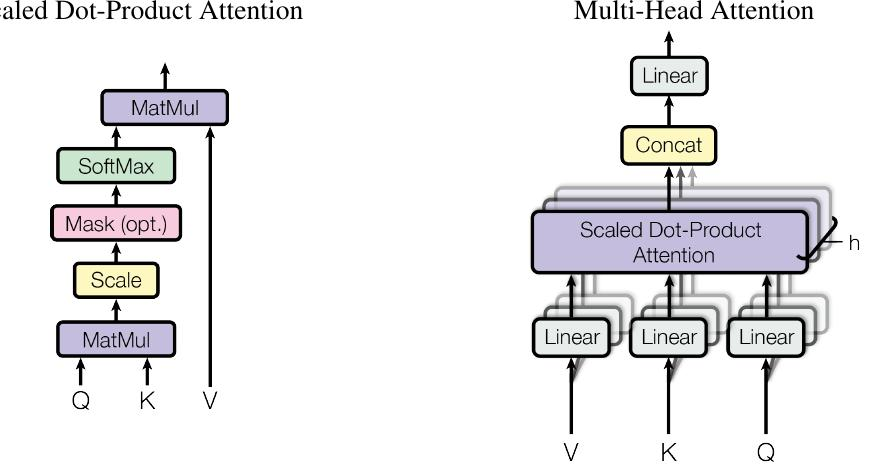

In [63]:
# ── Query with source ─────────────────────────────────────────────────────────

response = chain_with_source.invoke("Explain scaled dot-product attention?")

print("Response:", response["response"], "\n")
print("-" * 80, "\nSource Documents:")

for doc in response["context"]["text"]:
    if isinstance(doc, ExtractedDoc):
        print(f"  [page {doc.page_number}] {doc.content[:120]}...")
    else:
        print(f"  {str(doc)[:120]}...")

print(f"\n  Images in context: {len(response['context']['images'])}")
for img in response["context"]["images"]:
    display_base64_image(img)


---
## 8. CLIP Shared Semantic Space

**Strategy**: text chunks and images are embedded directly in a **shared vector space** using a CLIP model.  
No summarization step is required — CLIP text encoder handles text, CLIP image encoder handles visuals.

The key difference from the VLM pipeline:
| Aspect | VLM Summarization (Section 3–7) | CLIP Shared Space (Section 8–10) |
|---|---|---|
| Image representation | VLM-generated text summary | Raw CLIP image embedding |
| Text representation | Sentence-transformer embedding of summary | CLIP text embedding of raw chunk |
| BM25 | On VLM summaries | On raw text chunk content |
| Qdrant collection | `QDRANT_COLLECTION` | `QDRANT_CLIP_COLLECTION` (separate) |
| Dim conflict | n/a | Different dim → **must** use separate collection |


### 8.1 CLIP Configuration

In [64]:
# ── CLIP model ────────────────────────────────────────────────────────────────
# open_clip model string (arch → pretrained checkpoint mapping inside CLIPEmbedder).
# "laion/CLIP-ViT-B-32-laion2B-s34B-b79K"  — 512-dim, fast   (default)
# "laion/CLIP-ViT-L-14-laion2B-s32B-b82K"  — 768-dim, better
# "openai/clip-vit-base-patch32"            — 512-dim, original OpenAI
# "openai/clip-vit-large-patch14"           — 768-dim, original OpenAI large
CLIP_MODEL      = os.getenv("CLIP_MODEL",      "laion/CLIP-ViT-B-32-laion2B-s34B-b79K")
# CLIP_MODEL    = os.getenv("CLIP_MODEL",      "openai/clip-vit-base-patch32")
CLIP_BATCH_SIZE = int(os.getenv("CLIP_BATCH_SIZE", "32"))

# ── Separate Qdrant collection for CLIP ───────────────────────────────────────
# CLIP vectors have different dimensionality from the text-embedding model
# (e.g. CLIP ViT-B/32 = 512-dim vs BAAI/bge-m3 = 1024-dim).
# Using the SAME collection would raise a dimension mismatch error at insert time.
# A dedicated collection isolates the two pipelines completely.
QDRANT_CLIP_COLLECTION       = os.getenv("QDRANT_CLIP_COLLECTION",       QDRANT_COLLECTION + "_clip")
RESET_QDRANT_CLIP_COLLECTION = os.getenv("RESET_QDRANT_CLIP_COLLECTION", "false").lower() == "true"

print("CLIP configuration:")
print(f"  Model      : {CLIP_MODEL}")
print(f"  Batch size : {CLIP_BATCH_SIZE}")
print(f"  Collection : {QDRANT_CLIP_COLLECTION}  (isolated from '{QDRANT_COLLECTION}')")


CLIP configuration:
  Model      : laion/CLIP-ViT-B-32-laion2B-s34B-b79K
  Batch size : 32
  Collection : multirag_local_hf_clip  (isolated from 'multirag_local_hf')


### 8.2 CLIP Embedder

In [65]:
import torch
import open_clip
import numpy as np
import io
from PIL import Image as PILImage

class CLIPEmbedder:
    """
    Unified CLIP embedder for text and images.
    Uses open_clip to support OpenAI and LAION checkpoints.
    All outputs are L2-normalised (unit sphere) — cosine sim == dot product.
    """

    # Maps HuggingFace-style IDs → (open_clip arch, pretrained tag)
    HF_TO_OPENCLIP = {
        "laion/CLIP-ViT-B-32-laion2B-s34B-b79K": ("ViT-B-32", "laion2b_s34b_b79k"),
        "laion/CLIP-ViT-L-14-laion2B-s32B-b82K": ("ViT-L-14", "laion2b_s32b_b82k"),
        "laion/CLIP-ViT-H-14-laion2B-s32B-b79K": ("ViT-H-14", "laion2b_s32b_b79k"),
        "openai/clip-vit-base-patch32":           ("ViT-B-32", "openai"),
        "openai/clip-vit-large-patch14":          ("ViT-L-14", "openai"),
    }

    def __init__(self, model_id: str, batch_size: int = 32):
        self.model_id   = model_id
        self.batch_size = batch_size
        self.device     = "cuda" if torch.cuda.is_available() else "cpu"

        if model_id not in self.HF_TO_OPENCLIP:
            raise ValueError(
                f"Unknown CLIP model: {model_id!r}.\n"
                f"Supported: {list(self.HF_TO_OPENCLIP.keys())}"
            )

        arch, pretrained = self.HF_TO_OPENCLIP[model_id]
        print(f"Loading CLIP: arch={arch}, pretrained={pretrained}, device={self.device} ...")

        self.model, _, self.preprocess = open_clip.create_model_and_transforms(
            arch, pretrained=pretrained
        )
        self.tokenizer = open_clip.get_tokenizer(arch)
        self.model.eval().to(self.device)

        # Infer embedding dimension via a single forward pass
        with torch.no_grad():
            dummy   = torch.zeros(1, 3, 224, 224).to(self.device)
            self.dim = self.model.encode_image(dummy).shape[-1]

        print(f"  ✓ CLIP ready — dim={self.dim}")

    def encode_texts(self, texts: List[str]) -> np.ndarray:
        """Encode a list of strings → (N, dim) float32 array, L2-normalised."""
        all_vecs = []
        for i in range(0, len(texts), self.batch_size):
            batch  = texts[i : i + self.batch_size]
            tokens = self.tokenizer(batch).to(self.device)
            with torch.no_grad():
                vecs = self.model.encode_text(tokens).float()
                vecs = torch.nn.functional.normalize(vecs, dim=-1)
            all_vecs.append(vecs.cpu().numpy())
        return np.vstack(all_vecs) if all_vecs else np.empty((0, self.dim))

    def encode_pil_images(self, images: List[PILImage.Image]) -> np.ndarray:
        """Encode a list of PIL Images → (N, dim) float32 array, L2-normalised."""
        all_vecs = []
        for i in range(0, len(images), self.batch_size):
            batch   = images[i : i + self.batch_size]
            tensors = torch.stack([self.preprocess(img) for img in batch]).to(self.device)
            with torch.no_grad():
                vecs = self.model.encode_image(tensors).float()
                vecs = torch.nn.functional.normalize(vecs, dim=-1)
            all_vecs.append(vecs.cpu().numpy())
        return np.vstack(all_vecs) if all_vecs else np.empty((0, self.dim))

    def encode_doc(self, doc: "ExtractedDoc") -> np.ndarray:
        """Dispatch to the correct encoder based on doc_type."""
        if doc.doc_type in ("image", "table_image"):
            raw = base64.b64decode(doc.content)
            img = PILImage.open(io.BytesIO(raw)).convert("RGB")
            return self.encode_pil_images([img])[0]
        else:
            return self.encode_texts([doc.content])[0]


# ── Load CLIP ─────────────────────────────────────────────────────────────────
try:
    clip_embedder  = CLIPEmbedder(CLIP_MODEL, batch_size=CLIP_BATCH_SIZE)
    CLIP_AVAILABLE = True
except Exception as e:
    print(f"✗ CLIP loading failed: {e}")
    clip_embedder  = None
    CLIP_AVAILABLE = False


Loading CLIP: arch=ViT-B-32, pretrained=laion2b_s34b_b79k, device=cuda ...
  ✓ CLIP ready — dim=512


### 8.3 Qdrant CLIP Collection

Uses the **same Qdrant Docker instance** as the VLM pipeline but a **dedicated collection** with the correct CLIP vector dimension.

In [66]:
from qdrant_client.http.models import Distance, VectorParams, PointStruct

# client is already initialised in Section 4 — reuse it
if CLIP_AVAILABLE:
    if RESET_QDRANT_CLIP_COLLECTION and client.collection_exists(QDRANT_CLIP_COLLECTION):
        client.delete_collection(QDRANT_CLIP_COLLECTION)
        print(f"✓ Deleted existing CLIP collection '{QDRANT_CLIP_COLLECTION}'.")

    if not client.collection_exists(QDRANT_CLIP_COLLECTION):
        client.create_collection(
            collection_name = QDRANT_CLIP_COLLECTION,
            vectors_config  = VectorParams(size=clip_embedder.dim, distance=Distance.COSINE),
        )
        print(f"✓ Created CLIP Qdrant collection '{QDRANT_CLIP_COLLECTION}' (dim={clip_embedder.dim}).")
    else:
        print(f"✓ Using existing CLIP Qdrant collection '{QDRANT_CLIP_COLLECTION}'.")
else:
    print("CLIP not available — skipping collection setup.")

# ── Dedicated docstore for the CLIP pipeline ──────────────────────────────────
# A plain dict is sufficient: UUID → ExtractedDoc.
# Using a separate variable avoids any collision with the VLM pipeline's InMemoryStore.
clip_docstore: dict = {}


✓ Using existing CLIP Qdrant collection 'multirag_local_hf_clip'.


### 8.4 Indexing with CLIP

Text chunks are encoded with the **CLIP text encoder**; images with the **CLIP image encoder**. Both land in the same Qdrant CLIP collection, making cross-modal retrieval possible.

In [67]:
def index_documents_clip(
    docs: List[ExtractedDoc],
    batch_size: int = CLIP_BATCH_SIZE,
) -> List[str]:
    """
    Embed and index all ExtractedDocs (text + visual) into the CLIP Qdrant collection.

    Text chunks  → CLIP text encoder
    Images/tables → CLIP image encoder

    Each point is stored with a UUID payload that links back to clip_docstore.
    Returns the list of generated UUIDs.
    """
    if not CLIP_AVAILABLE:
        print("CLIP not available — skipping indexing.")
        return []

    text_list   = [d for d in docs if d.doc_type == "text"]
    visual_list = [d for d in docs if d.doc_type in ("image", "table_image")]
    all_ids: List[str] = []
    points: List[PointStruct] = []

    # ── Encode text chunks ────────────────────────────────────────────────────
    print(f"Encoding {len(text_list)} text chunks with CLIP text encoder ...")
    for i in range(0, len(text_list), batch_size):
        batch = text_list[i : i + batch_size]
        try:
            vecs = clip_embedder.encode_texts([d.content for d in batch])
        except Exception as e:
            print(f"  ✗ Text batch {i//batch_size}: {e}")
            vecs = np.zeros((len(batch), clip_embedder.dim), dtype=np.float32)
        for doc, vec in zip(batch, vecs):
            uid = str(uuid.uuid4())
            all_ids.append(uid)
            clip_docstore[uid] = doc
            points.append(PointStruct(
                id      = uid,
                vector  = vec.tolist(),
                payload = {
                    "doc_type": doc.doc_type,
                    "page":     doc.page_number,
                    "source":   doc.source_file,
                    "preview":  doc.content[:120],
                },
            ))
        print(f"  [{min(i + batch_size, len(text_list))}/{len(text_list)}] text chunks encoded")

    # ── Encode visual elements ────────────────────────────────────────────────
    print(f"Encoding {len(visual_list)} visual elements with CLIP image encoder ...")
    for i, doc in enumerate(visual_list):
        try:
            raw = base64.b64decode(doc.content)
            img = PILImage.open(io.BytesIO(raw)).convert("RGB")
            vec = clip_embedder.encode_pil_images([img])[0]
            print(f"  [{i+1}/{len(visual_list)}] ✓ type={doc.doc_type} page={doc.page_number}")
        except Exception as e:
            print(f"  [{i+1}/{len(visual_list)}] ✗ Error: {e} — using zero vector")
            vec = np.zeros(clip_embedder.dim, dtype=np.float32)
        uid = str(uuid.uuid4())
        all_ids.append(uid)
        clip_docstore[uid] = doc
        points.append(PointStruct(
            id      = uid,
            vector  = vec.tolist(),
            payload = {
                "doc_type": doc.doc_type,
                "page":     doc.page_number,
                "source":   doc.source_file,
                "preview":  "[image]",
            },
        ))

    # ── Batch insert into Qdrant ──────────────────────────────────────────────
    UPSERT_BATCH = 100
    print(f"\nInserting {len(points)} vectors into '{QDRANT_CLIP_COLLECTION}' ...")
    inserted = 0
    for i in range(0, len(points), UPSERT_BATCH):
        batch = points[i : i + UPSERT_BATCH]
        try:
            client.upsert(collection_name=QDRANT_CLIP_COLLECTION, points=batch)
            inserted += len(batch)
        except Exception as e:
            print(f"  ✗ Upsert batch {i//UPSERT_BATCH}: {e}")

    print(
        f"CLIP indexing complete: {len(text_list)} text + {len(visual_list)} visual "
        f"= {inserted}/{len(points)} vectors inserted."
    )
    return all_ids


In [68]:
clip_doc_ids = index_documents_clip(extracted_docs)
image_uuids = [i for i, d in enumerate(clip_docstore.values()) if d.doc_type in ('image','table_image')]
print(f"\nclip_docstore size: {len(clip_docstore)}")
print(f"Text entries : {sum(1 for d in clip_docstore.values() if d.doc_type == 'text')}")
print(f"Visual entries: {sum(1 for d in clip_docstore.values() if d.doc_type in ('image','table_image'))}")


Encoding 28 text chunks with CLIP text encoder ...
  [28/28] text chunks encoded
Encoding 6 visual elements with CLIP image encoder ...
  [1/6] ✓ type=image page=3
  [2/6] ✓ type=image page=4
  [3/6] ✓ type=image page=13
  [4/6] ✓ type=image page=14
  [5/6] ✓ type=image page=15
  [6/6] ✓ type=image page=15

Inserting 34 vectors into 'multirag_local_hf_clip' ...
CLIP indexing complete: 28 text + 6 visual = 34/34 vectors inserted.

clip_docstore size: 34
Text entries : 28
Visual entries: 6


### 8.5 CLIP BM25 Index (Text Chunks Only)

BM25 operates on raw text tokens — no summaries, since CLIP skips the summarization step.  
Visual elements are retrieved exclusively via CLIP dense search.

In [69]:
# clip_bm25_index: separate from bm25_index (which was built on VLM summaries)
clip_bm25_index = BM25Index()  # reuse the BM25Index class defined in Section 5

if ENABLE_BM25:
    # Build on raw text content (not summaries — there are none in this pipeline)
    raw_text_contents = [d.content for d in text_docs]
    raw_text_pairs    = [(c, d) for c, d in zip(raw_text_contents, text_docs) if c.strip()]
    clip_bm25_index.build(
        summaries = [c for c, _ in raw_text_pairs],
        docs      = [d for _, d in raw_text_pairs],
    )
else:
    print("BM25 disabled (ENABLE_BM25=False).")


BM25 index built on 28 documents.


### 8.6 CLIP Hybrid Retrieval

Same three-stage structure as the VLM pipeline:
1. **CLIP dense search** via Qdrant — retrieves text *and* image candidates in the shared space
2. **BM25** on raw text chunks (optional)
3. **Cross-encoder reranking** on text candidates — visual candidates bypass reranking (cross-encoders are text-only)

In [70]:
def clip_hybrid_retrieve(query: str) -> List[ExtractedDoc]:
    """
    CLIP-based hybrid retrieval pipeline.
    Mirrors hybrid_retrieve() from Section 5 but uses:
      - CLIP text encoder for query embedding
      - QDRANT_CLIP_COLLECTION for dense search
      - clip_bm25_index (built on raw text, not summaries)
      - clip_docstore for UUID resolution
    Reuses the same reranker and RETRIEVER_K / RERANKER_TOP_N globals.
    """
    if not CLIP_AVAILABLE:
        print("[clip_hybrid_retrieve] CLIP not available.")
        return []

    seen_content: set           = set()
    text_cands:   List[tuple]   = []   # (snippet_for_rerank, ExtractedDoc)
    visual_cands: List[ExtractedDoc] = []

    # ── 1. CLIP dense retrieval ───────────────────────────────────────────────
    n_dense_hits = 0
    try:
        query_vec = clip_embedder.encode_texts([query])[0].tolist()
        hits = client.query_points(
            collection_name = QDRANT_CLIP_COLLECTION,
            query           = query_vec,
            limit           = RETRIEVER_K,
            with_payload    = True,
        ).points
        n_dense_hits = len(hits)
        for hit in hits:
            doc = clip_docstore.get(str(hit.id))
            if doc is None or doc.content in seen_content:
                continue
            seen_content.add(doc.content)
            if doc.doc_type in ("image", "table_image"):
                visual_cands.append(doc)
            else:
                text_cands.append((doc.content[:500], doc))
    except Exception as e:
        print(f"[clip_hybrid_retrieve] Dense retrieval error: {e}")

    # ── 2. BM25 retrieval (text only) ─────────────────────────────────────────
    if ENABLE_BM25:
        for score, doc in clip_bm25_index.retrieve(query, top_k=RETRIEVER_K):
            if doc.content not in seen_content:
                seen_content.add(doc.content)
                text_cands.append((doc.content[:500], doc))

    if not text_cands and not visual_cands:
        print("[clip_hybrid_retrieve] No candidates found.")
        return []

    # ── 3. Cross-encoder reranking (text candidates only) ────────────────────
    if text_cands and ENABLE_RERANKING and RERANKER_AVAILABLE and reranker is not None:
        pairs  = [(query, s) for s, _ in text_cands]
        scores = reranker.predict(pairs)
        ranked = sorted(
            zip(scores, [d for _, d in text_cands]),
            key=lambda x: x[0], reverse=True,
        )
        top_text = [d for _, d in ranked[:RERANKER_TOP_N]]
    else:
        top_text = [d for _, d in text_cands[:RERANKER_TOP_N]]

    max_visual = max(0, RERANKER_TOP_N - len(top_text))
    top_visual = visual_cands[:max_visual]
    final      = top_text + top_visual

    print(
        f"[clip_hybrid_retrieve] dense={n_dense_hits}, "
        f"bm25_text={len(text_cands)}, visual={len(visual_cands)} → "
        f"final={len(final)} (text={len(top_text)}, visual={len(top_visual)})"
    )
    return final


# ── Sanity check ──────────────────────────────────────────────────────────────
clip_test = clip_hybrid_retrieve("What is scaled dot-product attention?")
print(f"\nRetrieved {len(clip_test)} docs:")
for i, d in enumerate(clip_test):
    print(f"  [{i}] type={d.doc_type} page={d.page_number} | {d.content[:80]!r}")


[clip_hybrid_retrieve] dense=10, bm25_text=10, visual=0 → final=5 (text=5, visual=0)

Retrieved 5 docs:
  [0] type=text page=4 | '3.2.1 Scaled Dot-Product Attention\n\nWe call our particular attention "Scaled Dot'
  [1] type=text page=3 | '3.2. Attention\n\nAn attention function can be described as mapping a query and a '
  [2] type=text page=5 | '3.2.3. Applications of Attention in our Model\n\nThe Transformer uses multi-head a'
  [3] type=text page=6 | '4 Why Self-Attention\n\nIn this section we compare various aspects of self-attenti'
  [4] type=text page=5 | '3.3 Position-wise Feed-Forward Networks\n\nIn addition to attention sub-layers, ea'


---
### 9. CLIP RAG Generation

Reuses the **same local generation model** loaded in Section 6 (`local_generate_answer`, `parse_docs`).  
No additional model loading required.


In [71]:
class CLIPRAGOutputChain:
    """RAG chain using CLIP retrieval + same local generation model."""
    def invoke(self, question: str) -> str:
        context = parse_docs(clip_hybrid_retrieve(question))
        return local_generate_answer(context, question)

class CLIPRAGChainWithSource:
    """RAG chain with CLIP retrieval that also returns source documents."""
    def invoke(self, question: str) -> dict:
        context  = parse_docs(clip_hybrid_retrieve(question))
        response = local_generate_answer(context, question)
        return {"context": context, "question": question, "response": response}

clip_output_chain      = CLIPRAGOutputChain()
clip_chain_with_source = CLIPRAGChainWithSource()
print("CLIP RAG chains ready (generation model:", GENERATION_MODEL, ")")


CLIP RAG chains ready (generation model: mistral-nemo:latest )


In [72]:
# ── Answer only ───────────────────────────────────────────────────────────────
clip_answer = clip_output_chain.invoke("What do the authors mean by 'attention'?")
print("CLIP pipeline answer:")
print(clip_answer)


[clip_hybrid_retrieve] dense=10, bm25_text=10, visual=0 → final=5 (text=5, visual=0)
CLIP pipeline answer:
The authors define "attention" as a function that maps a query and a set of key-value pairs to an output, where the output is computed as a weighted sum of the values, with weights determined by a compatibility function between the query and each corresponding key. This allows the model to selectively focus on different parts of the input sequence when generating an output.


In [73]:
# ── Answer with sources ───────────────────────────────────────────────────────
clip_response = clip_chain_with_source.invoke("Explain scaled dot-product attention?")

print("Response:", clip_response["response"], "\n")
print("-" * 80, "\nSource Documents:")
for doc in clip_response["context"]["text"]:
    print(f"  [page {doc.page_number}] {doc.content[:120]}...")
print(f"\n  Images in context: {len(clip_response['context']['images'])}")
for img in clip_response["context"]["images"]:
    display_base64_image(img)


[clip_hybrid_retrieve] dense=10, bm25_text=5, visual=0 → final=5 (text=5, visual=0)
Response: Scaled Dot-Product Attention is a particular attention mechanism used in the Transformer model. It takes queries and keys of dimension dx as inputs, along with values of dimension d_v. The process involves computing the dot products of the query with all keys, dividing each by √d_k (where d_k is the dimension of keys), and then applying a softmax function to obtain weights on the values. These weighted sums of values are used to compute the output matrix. This mechanism is faster and more space-efficient than additive attention due to its use of highly optimized matrix multiplication code, but it requires scaling by √d_k for large values of d_k to prevent extremely small gradients in the softmax function. 

-------------------------------------------------------------------------------- 
Source Documents:
  [page 4] 3.2.1 Scaled Dot-Product Attention

We call our particular attention "Scaled D

---
## 9. Option 3 — VLM Summary Only (no raw image to LLM)

The notebook now implements three retrieval+generation variants, fully
covering the design space described in the multi-vector retriever literature:

| Option | Retrieval | LLM input | Generator type |
|---|---|---|---|
| **1. CLIP shared space** | text + image embeddings (cross-modal) | raw text + raw images | multimodal |
| **2. VLM + raw image** (default in §6) | summary embeddings | raw text + raw images | multimodal |
| **3. VLM summary only** (this section) | summary embeddings | raw text + **VLM image summaries** | text-only |

Option 3 is the **purest unified translation**: at generation time the LLM never
sees the original image — only its textual description produced by the VLM at
indexing time. This is the variant compatible with any text-only LLM (Mistral,
Llama 3, Qwen2.5 base, etc.) and removes the dependency on a multimodal generator.

The trade-off is information loss: anything the VLM summary missed cannot be
recovered at generation. This makes Option 3 a fair baseline for measuring
*how much* the raw image actually helps the final answer.


### 9.1 Build the VLM Summary Docstore

In [74]:
# For Option 3 we need fast lookup from each image/table document to its VLM summary.
# Keep both content- and UUID-based maps so retrieval outputs from either pipeline can be scored.
valid_image_summary_pairs = [
    (doc, summary)
    for doc, summary in zip(image_docs, image_summaries)
    if summary and not summary.startswith("[")
]
vlm_image_summary_by_content: Dict[str, str] = {
    doc.content: summary for doc, summary in valid_image_summary_pairs
}
vlm_image_summary_by_uuid: Dict[str, str] = {}
for uid in image_uuids:
    stored = retriever.docstore.mget([uid])[0]
    if stored is not None:
        summary = vlm_image_summary_by_content.get(stored.content)
        if summary:
            vlm_image_summary_by_uuid[uid] = summary

# Convenience: build a parallel docstore where image entries carry the SUMMARY
# as their content (instead of the raw base64). This is what gets passed to the
# text-only LLM during Option 3 generation.
class _SummaryDoc:
    """Minimal ExtractedDoc-compatible wrapper carrying a VLM summary as content."""
    def __init__(self, summary: str, original: ExtractedDoc):
        self.content      = summary
        self.doc_type     = "text"              # treat as text for the LLM
        self.page_number  = original.page_number
        self.source_file  = original.source_file
        self.original_doc_type = original.doc_type   # 'image' or 'table_image'
        self._original_b64     = original.content    # kept for debugging only

print(
    f"VLM summary docstore: {len(vlm_image_summary_by_uuid)} UUID summaries, "
    f"{len(vlm_image_summary_by_content)} content summaries."
)


VLM summary docstore: 0 UUID summaries, 6 content summaries.


### 9.2 Option 3 Generation

In [75]:
def parse_docs_summary_only(docs) -> dict:
    """
    Variant of parse_docs() that substitutes each retrieved image with its
    VLM-generated TEXT summary. Returns the same structure as parse_docs() but
    with an empty 'images' list — guaranteeing the LLM receives no raw image.
    """
    images_as_text: List[_SummaryDoc] = []
    texts:          List[ExtractedDoc] = []

    for doc in docs:
        # Resolve to an ExtractedDoc if needed
        if isinstance(doc, ExtractedDoc):
            ed = doc
        else:
            content  = getattr(doc, "page_content", str(doc))
            doc_type = doc.metadata.get("doc_type", "text") if hasattr(doc, "metadata") else "text"
            ed       = ExtractedDoc(content=content, doc_type=doc_type)

        if ed.doc_type in ("image", "table_image"):
            # Find the VLM summary for this image by content match
            # (the docstore is keyed by UUID; we match on raw content here).
            summary = vlm_image_summary_by_content.get(ed.content)
            if summary is None:
                for uid, summ in vlm_image_summary_by_uuid.items():
                    stored = retriever.docstore.mget([uid])[0]
                    if stored is not None and stored.content == ed.content:
                        summary = summ
                        break
            if summary is None:
                summary = "[VLM summary unavailable for this image]"
            images_as_text.append(_SummaryDoc(summary, ed))
        else:
            texts.append(ed)

    # All visual context is folded into the text channel as VLM-generated text.
    merged_texts: List[Any] = list(texts) + images_as_text
    return {"images": [], "text": merged_texts}


def generate_answer_summary_only(docs_by_type: dict, user_question: str) -> str:
    """
    Generation for Option 3.
    Forces a text-only prompt: all retrieved images are represented exclusively
    by their VLM summaries. Works with any text-only LLM, including Ollama.
    """
    if not GENERATOR_AVAILABLE:
        return "[Generation unavailable]"

    # Build a text-only context that explicitly labels image-derived chunks
    context_parts = []
    for doc in docs_by_type["text"]:
        if isinstance(doc, _SummaryDoc):
            page = f" (page {doc.page_number})" if doc.page_number else ""
            label = "image summary" if doc.original_doc_type == "image" else "table summary"
            context_parts.append(f"[{label}{page}]\n{doc.content}")
        elif isinstance(doc, ExtractedDoc):
            page = f" (page {doc.page_number})" if doc.page_number else ""
            context_parts.append(f"[{doc.doc_type}{page}]\n{doc.content}")
        else:
            context_parts.append(getattr(doc, "page_content", str(doc)))

    context_text = "\n\n".join(context_parts) if context_parts else "[No context]"
    prompt_text = (
        "Answer the question using only the provided context. "
        "Image and table content is represented by short textual descriptions. "
        "If the context is insufficient, say so explicitly.\n\n"
        f"Context:\n{context_text}\n\n"
        f"Question: {user_question}"
    )

    # Ollama path
    if globals().get("USE_OLLAMA_GENERATOR", False):
        return _invoke_ollama_generator(prompt_text)

    # HF text-only path — works with Qwen2.5-3B-Instruct and similar
    if not GENERATION_IS_VLM and gen_text_model is not None:
        messages = [{"role": "user", "content": prompt_text}]
        if hasattr(gen_tokenizer, "apply_chat_template"):
            text = gen_tokenizer.apply_chat_template(messages, tokenize=False,
                                                      add_generation_prompt=True)
        else:
            text = prompt_text
        inputs = gen_tokenizer([text], return_tensors="pt").to(gen_text_model.device)
        with torch.no_grad():
            out = gen_text_model.generate(
                **inputs, max_new_tokens=GENERATION_MAX_NEW_TOKENS,
                do_sample=False, temperature=None,
                pad_token_id=gen_tokenizer.eos_token_id,
            )
        return gen_tokenizer.batch_decode(
            out[:, inputs.input_ids.shape[1]:], skip_special_tokens=True)[0].strip()

    # If the configured GENERATION_MODEL is a VLM, still run it text-only by
    # simply not passing any image. The model handles plain text prompts fine.
    if GENERATION_IS_VLM and gen_vl_model is not None:
        messages = [{"role": "user", "content": [{"type": "text", "text": prompt_text}]}]
        text_input = gen_vl_processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True)
        inputs = gen_vl_processor(text=[text_input], padding=True,
                                   return_tensors="pt").to(gen_vl_model.device)
        with torch.no_grad():
            generated = gen_vl_model.generate(**inputs,
                                              max_new_tokens=GENERATION_MAX_NEW_TOKENS)
        trimmed = [out[len(inp):] for inp, out in zip(inputs.input_ids, generated)]
        return gen_vl_processor.batch_decode(
            trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0].strip()

    return "[No generator available]"


class VLMSummaryOnlyRAGChain:
    """Option 3 RAG chain: VLM-summary retrieval + summary-only text generation."""
    def invoke(self, question: str) -> str:
        retrieved = hybrid_retrieve(question)               # same retriever as Option 2
        context   = parse_docs_summary_only(retrieved)
        return generate_answer_summary_only(context, question)

    def invoke_with_source(self, question: str) -> dict:
        retrieved = hybrid_retrieve(question)
        context   = parse_docs_summary_only(retrieved)
        answer    = generate_answer_summary_only(context, question)
        return {"context": context, "question": question, "response": answer,
                "retrieved": retrieved}

summary_only_chain = VLMSummaryOnlyRAGChain()
print("Option 3 chain ready: VLM summary retrieval + text-only generation.")


Option 3 chain ready: VLM summary retrieval + text-only generation.


In [76]:
# Smoke test
answer_opt3 = summary_only_chain.invoke("What is multi-head attention?")
print("Option 3 answer:")
print(answer_opt3)


[hybrid_retrieve] 10 candidates → 5 after rerank (query: 'What is multi-head attention?')
Option 3 answer:
Multi-head attention involves using multiple attention mechanisms (heads) in parallel. Each head processes query, key, and value vectors through separate learned linear projections before applying the attention function. The outputs of these heads are concatenated and reprojected into the original vector space size \(d\). This approach enables the model to attend to information from various representations simultaneously, enhancing its ability to capture diverse features.


---
## 10. Evaluation

This section evaluates the three RAG approaches with answer-level and retrieval-level metrics:

| Metric | What it checks |
|---|---|
| `BERTScore` | semantic similarity between generated and expected answer |
| `Precision` / `Recall` | lexical overlap of answer tokens against the expected answer |
| `Context Recall` | how many annotated claims are present in retrieved context |
| `Visual Claim Recall` | how many visual/both-source claims appear in the generated answer |
| `Must` / `Should` recall | claim coverage split by required vs desirable facts |

The claim-level metrics use the `claims` list in each test item. `must` claims represent required facts; `should` claims represent useful supporting details.


### 10.1 Test Questions and Annotated Claims


In [77]:
TEST_SET = [
    {
        "question": "Describe the overall architecture of the Transformer model",
        
        "expected_answer":
            "The Transformer uses an encoder-decoder architecture. The encoder consists "
            "of 6 identical layers, each with multi-head self-attention and position-wise "
            "feed-forward networks. The decoder also has 6 layers with an additional "
            "masked self-attention mechanism and encoder-decoder attention. Residual "
            "connections and layer normalization are applied around each sub-layer.",
        
        "claims": [
            {
                "text": "The Transformer has an encoder-decoder architecture",
                "importance": "must",
                "source": "visual"  # architecture diagram
            },
            {
                "text": "The encoder has 6 identical layers",
                "importance": "must",
                "source": "visual"
            },
            {
                "text": "Each encoder layer contains multi-head self-attention and feed-forward networks",
                "importance": "must",
                "source": "visual"
            },
            {
                "text": "The decoder also has 6 layers",
                "importance": "should",
                "source": "visual"
            },
            {
                "text": "The decoder includes masked self-attention and encoder-decoder attention",
                "importance": "should",
                "source": "visual"
            },
            {
                "text": "Residual connections and layer normalization are used",
                "importance": "should",
                "source": "visual"
            },
        ],
        
        "requires_continuity": False,
        "requires_visual": True,
        
        # Legacy keywords (naive testing approach - kept for reference)
        "context_keywords": ["encoder", "decoder", "layers", "self-attention", "feed-forward"],
        "answer_keywords": ["encoder", "decoder", "6 layers", "attention", "residual"],
    },
    

    {
        "question": "What BLEU scores did the Transformer achieve on WMT 2014 English-to-German translation?",
        
        "expected_answer":
            "The Transformer (big) model achieved 28.4 BLEU on the WMT 2014 English-to-German "
            "translation task, outperforming previous state-of-the-art models including ensembles.",
        
        "claims": [
            {
                "text": "The model achieved 28.4 BLEU on WMT 2014 EN-DE",
                "importance": "must",
                "source": "visual"  # results table
            },
            {
                "text": "This outperformed previous state-of-the-art",
                "importance": "should",
                "source": "both"  # table + text discussion
            },
            {
                "text": "The big model configuration was used",
                "importance": "should",
                "source": "visual"  # table row label
            },
        ],
        
        "requires_continuity": False,
        "requires_visual": True,
        
        # Legacy keywords
        "context_keywords": ["BLEU", "28.4", "WMT", "2014", "English", "German"],
        "answer_keywords": ["28.4", "BLEU", "WMT 2014"],
    },
    

    {
        "question": "What is the formula for scaled dot-product attention?",
        
        "expected_answer":
            "The scaled dot-product attention is computed as Attention(Q, K, V) = "
            "softmax(QK^T / sqrt(d_k)) V, where Q are queries, K are keys, V are values, "
            "and d_k is the dimension of the keys.",
        
        "claims": [
            {
                "text": "The formula is softmax of QK transpose divided by square root of d_k, times V",
                "importance": "must",
                "source": "visual"  # equation in paper/slide
            },
            {
                "text": "Q represents queries, K represents keys, V represents values",
                "importance": "must",
                "source": "both"
            },
            {
                "text": "d_k is the dimension of the keys",
                "importance": "should",
                "source": "text"
            },
            {
                "text": "The scaling factor prevents gradients from becoming too small",
                "importance": "should",
                "source": "text"
            },
        ],
        
        "requires_continuity": False,
        "requires_visual": True,
        
        # Legacy keywords
        "context_keywords": ["softmax", "dot product", "queries", "keys", "values", "sqrt", "d_k"],
        "answer_keywords": ["softmax", "QK", "sqrt", "d_k", "V"],
    },
    

    {
        "question": "What is positional encoding and why is it necessary in the Transformer?",
        
        "expected_answer":
            "Positional encodings are added to the input embeddings to inject information about "
            "the relative or absolute position of tokens in the sequence. They are necessary "
            "because the Transformer contains no recurrence or convolution, so it has no inherent "
            "notion of token order. The paper uses sine and cosine functions of different frequencies.",
        
        "claims": [
            {
                "text": "Positional encodings are added to input embeddings",
                "importance": "must",
                "source": "text"
            },
            {
                "text": "They provide information about token position in the sequence",
                "importance": "must",
                "source": "text"
            },
            {
                "text": "The Transformer has no recurrence or convolution",
                "importance": "must",
                "source": "text"
            },
            {
                "text": "Therefore it needs explicit position information",
                "importance": "should",
                "source": "text"
            },
            {
                "text": "Sine and cosine functions of different frequencies are used",
                "importance": "should",
                "source": "visual"  # formula/plot shown
            },
        ],
        
        "requires_continuity": True,   # spans motivation + solution
        "requires_visual": True,        # formula/plot helps understanding
        
        # Legacy keywords
        "context_keywords": ["positional", "encoding", "position", "sequence", "sine", "cosine"],
        "answer_keywords": ["position", "encoding", "sequence", "order"],
    },
    

    {
        "question": "What optimizer was used to train the Transformer?",
        
        "expected_answer":
            "The Transformer was trained using the Adam optimizer with beta1=0.9, beta2=0.98, "
            "and epsilon=1e-9. The learning rate was varied during training using a warmup "
            "schedule that increases linearly for the first warmup steps, then decreases "
            "proportionally to the inverse square root of the step number.",
        
        "claims": [
            {
                "text": "The Adam optimizer was used",
                "importance": "must",
                "source": "text"
            },
            {
                "text": "Beta1=0.9 and beta2=0.98",
                "importance": "should",
                "source": "text"
            },
            {
                "text": "A warmup learning rate schedule was used",
                "importance": "should",
                "source": "text"
            },
            {
                "text": "Learning rate increases linearly during warmup then decays",
                "importance": "should",
                "source": "text"
            },
        ],
        
        "requires_continuity": False,
        "requires_visual": False,
        
        # Legacy keywords
        "context_keywords": ["adam", "optimizer", "beta", "warmup", "learning rate"],
        "answer_keywords": ["adam", "warmup"],
    },

    {
        "question": "How does the decoder differ from the encoder in the Transformer?",
        
        "expected_answer":
            "The decoder has an additional masked multi-head self-attention layer that prevents "
            "positions from attending to subsequent positions, preserving the autoregressive "
            "property. It also includes an encoder-decoder attention sub-layer that attends "
            "over the encoder's output, whereas the encoder only has self-attention and "
            "feed-forward sub-layers.",
        
        "claims": [
            {
                "text": "The decoder has masked self-attention",
                "importance": "must",
                "source": "both"  # shown in diagram + explained
            },
            {
                "text": "Masking prevents attending to future positions",
                "importance": "must",
                "source": "text"
            },
            {
                "text": "The decoder includes encoder-decoder attention",
                "importance": "must",
                "source": "both"
            },
            {
                "text": "This preserves the autoregressive property",
                "importance": "should",
                "source": "text"
            },
            {
                "text": "The encoder only has self-attention and feed-forward layers",
                "importance": "should",
                "source": "both"
            },
        ],
        
        "requires_continuity": True,    # needs to discuss both components
        "requires_visual": False,        # diagram helps but explanation is textual
        
        # Legacy keywords
        "context_keywords": ["encoder", "decoder", "masked", "self-attention", "cross-attention"],
        "answer_keywords": ["decoder", "masked", "encoder-decoder attention"],
    },
    
    {
        "question": "Explain how multi-head attention works",
        
        "expected_answer":
            "Multi-head attention performs multiple attention operations in parallel. "
            "Instead of performing a single attention function, queries, keys and values "
            "are linearly projected h times with different learned projections. Attention "
            "is performed on each of these projected versions in parallel, then the outputs "
            "are concatenated and projected again to produce the final values.",
        
        "claims": [
            {
                "text": "Multi-head attention performs multiple attention operations in parallel",
                "importance": "must",
                "source": "both"
            },
            {
                "text": "Queries, keys, and values are linearly projected h times",
                "importance": "must",
                "source": "both"  # diagram shows heads, text explains projections
            },
            {
                "text": "Each projection uses different learned parameters",
                "importance": "should",
                "source": "text"
            },
            {
                "text": "Attention is performed on each projected version",
                "importance": "must",
                "source": "visual"  # parallel heads in diagram
            },
            {
                "text": "The outputs are concatenated and linearly projected",
                "importance": "should",
                "source": "both"
            },
        ],
        
        "requires_continuity": False,
        "requires_visual": True,         # diagram crucial for understanding parallel heads
        
        # Legacy keywords
        "context_keywords": ["multi-head", "attention", "parallel", "projection", "concatenate"],
        "answer_keywords": ["multi-head", "parallel", "projection", "heads"],
    },
]

TEST_SET_IMAGES = TEST_SET

print(f"Evaluation test set: {len(TEST_SET)} questions.")
print(f"  Visual questions   : {sum(1 for q in TEST_SET if q['requires_visual'])}")
print(f"  Text-only questions: {sum(1 for q in TEST_SET if not q['requires_visual'])}")
print(f"  Must claims        : {sum(1 for q in TEST_SET for c in q['claims'] if c['importance'] == 'must')}")
print(f"  Should claims      : {sum(1 for q in TEST_SET for c in q['claims'] if c['importance'] == 'should')}")


Evaluation test set: 7 questions.
  Visual questions   : 5
  Text-only questions: 2
  Must claims        : 16
  Should claims      : 16


### 10.2 Retrieval Views and RAG Approach Registry


In [78]:
import math
import re
from collections import defaultdict
from html import escape
from typing import Any, Callable, Iterable

try:
    import pandas as pd
except Exception as e:
    pd = None
    print(f"pandas unavailable; tables will be shown as raw lists. Error: {e}")

try:
    from IPython.display import HTML, clear_output, display
except Exception:
    HTML = None
    clear_output = None

try:
    from bert_score import score as bert_score_score
    BERTSCORE_AVAILABLE = True
except Exception as e:
    bert_score_score = None
    BERTSCORE_AVAILABLE = False
    print("bert_score package unavailable; using the transformers fallback for BERTScore.")

BERTSCORE_MODEL_TYPE = os.getenv("BERTSCORE_MODEL_TYPE", "distilbert-base-uncased")
CLAIM_MATCH_THRESHOLD = float(os.getenv("CLAIM_MATCH_THRESHOLD", "0.45"))
VISUAL_CLAIM_SOURCES = {"visual", "both"}
RETRIEVAL_STAGE_OPTIONS = {
    "dense": "Dense retrieval only",
    "bm25": "BM25 only",
    "hybrid": "Dense + BM25",
    "rerank": "Dense + BM25 + cross-encoder rerank",
}

_STOPWORDS = {
    "a", "an", "and", "are", "as", "at", "be", "because", "by", "for", "from",
    "has", "have", "in", "into", "is", "it", "its", "of", "on", "or", "over",
    "that", "the", "their", "then", "there", "this", "to", "used", "using", "was",
    "were", "with", "where", "which", "while",
}


def _normalize_text(text: str) -> str:
    text = str(text or "").lower()
    text = text.replace("^", " ").replace("_", "_")
    text = re.sub(r"[^a-z0-9_\.]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def _tokens(text: str) -> list[str]:
    return [t for t in _normalize_text(text).split() if len(t) > 1 and t not in _STOPWORDS]


def answer_precision_recall(candidate: str, reference: str) -> dict[str, float]:
    cand = set(_tokens(candidate))
    ref = set(_tokens(reference))
    if not cand and not ref:
        return {"precision": 1.0, "recall": 1.0, "answer_f1": 1.0}
    if not cand or not ref:
        return {"precision": 0.0, "recall": 0.0, "answer_f1": 0.0}
    overlap = len(cand & ref)
    precision = overlap / len(cand)
    recall = overlap / len(ref)
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {"precision": precision, "recall": recall, "answer_f1": f1}


def claim_match_score(claim_text: str, target_text: str) -> float:
    claim_tokens = set(_tokens(claim_text))
    target_tokens = set(_tokens(target_text))
    if not claim_tokens:
        return 0.0
    if _normalize_text(claim_text) and _normalize_text(claim_text) in _normalize_text(target_text):
        return 1.0
    token_recall = len(claim_tokens & target_tokens) / len(claim_tokens)
    token_precision = len(claim_tokens & target_tokens) / len(target_tokens) if target_tokens else 0.0
    token_f1 = 2 * token_precision * token_recall / (token_precision + token_recall) if token_precision + token_recall else 0.0
    return max(token_recall, token_f1)


def _filtered_claims(item: dict, importance: str | None = None, sources: set[str] | None = None) -> list[dict]:
    claims = item.get("claims", [])
    if importance is not None:
        claims = [c for c in claims if c.get("importance") == importance]
    if sources is not None:
        claims = [c for c in claims if c.get("source") in sources]
    return claims


def claim_recall(item: dict, target_text: str, importance: str | None = None, sources: set[str] | None = None) -> tuple[float, int, int]:
    claims = _filtered_claims(item, importance=importance, sources=sources)
    if not claims:
        return (math.nan, 0, 0)
    covered = sum(1 for c in claims if claim_match_score(c["text"], target_text) >= CLAIM_MATCH_THRESHOLD)
    return covered / len(claims), covered, len(claims)


def _lookup_visual_summary(doc: ExtractedDoc) -> str:
    if doc.doc_type not in ("image", "table_image"):
        return doc.content
    summary = globals().get("vlm_image_summary_by_content", {}).get(doc.content)
    if summary:
        return summary
    for uid, summ in globals().get("vlm_image_summary_by_uuid", {}).items():
        try:
            stored = retriever.docstore.mget([uid])[0]
        except Exception:
            stored = None
        if stored is not None and stored.content == doc.content:
            return summ
    return f"[{doc.doc_type} page={doc.page_number}; no VLM summary available]"


def retrieved_context_text(docs: list[ExtractedDoc]) -> str:
    parts = []
    for i, doc in enumerate(docs, start=1):
        page = f" page={doc.page_number}" if getattr(doc, "page_number", None) else ""
        if isinstance(doc, ExtractedDoc) and doc.doc_type in ("image", "table_image"):
            parts.append(f"[retrieved {i}: {doc.doc_type}{page}]\n{_lookup_visual_summary(doc)}")
        elif isinstance(doc, ExtractedDoc):
            parts.append(f"[retrieved {i}: {doc.doc_type}{page}]\n{doc.content}")
        else:
            parts.append(f"[retrieved {i}]\n{getattr(doc, 'page_content', str(doc))}")
    return "\n\n".join(parts)


def _dedupe_key(doc: ExtractedDoc) -> tuple:
    return (getattr(doc, "doc_type", "text"), getattr(doc, "page_number", None), hash(getattr(doc, "content", "")))


def _append_candidate(candidates: list[tuple[str, ExtractedDoc]], seen: set, rerank_text: str, doc: ExtractedDoc) -> None:
    key = _dedupe_key(doc)
    if key not in seen:
        seen.add(key)
        candidates.append((rerank_text or getattr(doc, "content", "")[:500], doc))


def _rerank_text_for_vlm_doc(doc: ExtractedDoc) -> str:
    if doc.doc_type in ("image", "table_image"):
        return _lookup_visual_summary(doc)
    return globals().get("vlm_text_summary_by_content", {}).get(doc.content, doc.content[:500])


def _rerank_text_for_clip_doc(doc: ExtractedDoc) -> str:
    if doc.doc_type in ("image", "table_image"):
        return _lookup_visual_summary(doc)
    return doc.content[:500]


vlm_text_summary_by_content = {
    doc.content: summary
    for doc, summary in zip(text_docs, text_summaries)
    if summary and not summary.startswith("[")
}


def retrieve_vlm_by_stage(query: str, stage: str = "rerank", k: int = RETRIEVER_K, top_n: int = RERANKER_TOP_N) -> list[ExtractedDoc]:
    """Parameterized retrieval for the VLM-summary index used by Option 2 and Option 3."""
    stage = stage if stage in RETRIEVAL_STAGE_OPTIONS else "rerank"
    seen: set = set()
    candidates: list[tuple[str, ExtractedDoc]] = []

    if stage in ("dense", "hybrid", "rerank"):
        try:
            for lc_doc in retriever.vectorstore.similarity_search(query, k=k):
                uid = lc_doc.metadata.get(ID_KEY)
                doc = retriever.docstore.mget([uid])[0] if uid else None
                if doc is None:
                    doc = ExtractedDoc(
                        content=lc_doc.page_content,
                        doc_type=lc_doc.metadata.get("doc_type", "text"),
                        page_number=lc_doc.metadata.get("page"),
                        source_file=lc_doc.metadata.get("source"),
                    )
                _append_candidate(candidates, seen, lc_doc.page_content, doc)
        except Exception as e:
            print(f"[retrieve_vlm_by_stage] Dense retrieval error: {e}")

    if stage in ("bm25", "hybrid", "rerank"):
        for score, doc in bm25_index.retrieve(query, top_k=k):
            _append_candidate(candidates, seen, _rerank_text_for_vlm_doc(doc), doc)

    if not candidates:
        return []

    if stage == "rerank" and RERANKER_AVAILABLE and reranker is not None:
        pairs = [(query, text) for text, _ in candidates]
        scores = reranker.predict(pairs)
        ranked = sorted(zip(scores, [d for _, d in candidates]), key=lambda x: x[0], reverse=True)
        return [d for _, d in ranked[:top_n]]
    return [d for _, d in candidates[:top_n]]


def retrieve_clip_by_stage(query: str, stage: str = "rerank", k: int = RETRIEVER_K, top_n: int = RERANKER_TOP_N) -> list[ExtractedDoc]:
    """Parameterized retrieval for the CLIP shared semantic-space index."""
    stage = stage if stage in RETRIEVAL_STAGE_OPTIONS else "rerank"
    if not globals().get("CLIP_AVAILABLE", False):
        return []

    seen: set = set()
    text_candidates: list[tuple[str, ExtractedDoc]] = []
    visual_candidates: list[ExtractedDoc] = []

    def add_clip_candidate(doc: ExtractedDoc, rerank_text: str) -> None:
        key = _dedupe_key(doc)
        if key in seen:
            return
        seen.add(key)
        if doc.doc_type in ("image", "table_image"):
            visual_candidates.append(doc)
        else:
            text_candidates.append((rerank_text, doc))

    if stage in ("dense", "hybrid", "rerank"):
        try:
            query_vec = clip_embedder.encode_texts([query])[0].tolist()
            hits = client.query_points(
                collection_name=QDRANT_CLIP_COLLECTION,
                query=query_vec,
                limit=k,
                with_payload=True,
            ).points
            for hit in hits:
                doc = clip_docstore.get(str(hit.id))
                if doc is not None:
                    add_clip_candidate(doc, _rerank_text_for_clip_doc(doc))
        except Exception as e:
            print(f"[retrieve_clip_by_stage] CLIP dense retrieval error: {e}")

    if stage in ("bm25", "hybrid", "rerank"):
        for score, doc in clip_bm25_index.retrieve(query, top_k=k):
            add_clip_candidate(doc, doc.content[:500])

    if not text_candidates and not visual_candidates:
        return []

    if stage == "rerank" and text_candidates and RERANKER_AVAILABLE and reranker is not None:
        pairs = [(query, text) for text, _ in text_candidates]
        scores = reranker.predict(pairs)
        ranked = sorted(zip(scores, [d for _, d in text_candidates]), key=lambda x: x[0], reverse=True)
        top_text = [d for _, d in ranked[:top_n]]
    else:
        top_text = [d for _, d in text_candidates[:top_n]]

    remaining = max(0, top_n - len(top_text))
    return top_text + visual_candidates[:remaining]


def generate_answer_for_approach(approach_key: str, question: str, docs: list[ExtractedDoc]) -> str:
    if approach_key == "vlm_summary":
        context = parse_docs_summary_only(docs)
        return generate_answer_summary_only(context, question)
    context = parse_docs(docs)
    return local_generate_answer(context, question)


RAG_APPROACHES = {
    "clip": {
        "label": "Option 1 - CLIP shared space",
        "retriever": retrieve_clip_by_stage,
        "description": "CLIP text/image embeddings; generator receives raw text and raw images.",
    },
    "vlm_raw": {
        "label": "Option 2 - VLM summaries + raw images",
        "retriever": retrieve_vlm_by_stage,
        "description": "Text/image summaries are indexed; generator receives raw text and raw images.",
    },
    "vlm_summary": {
        "label": "Option 3 - VLM summary only",
        "retriever": retrieve_vlm_by_stage,
        "description": "Same summary index as Option 2; image/table context is passed as VLM text summaries.",
    },
}

print("Evaluation harness ready.")
print("Retrieval views:")
for key, label in RETRIEVAL_STAGE_OPTIONS.items():
    print(f"  {key:>6}: {label}")


Evaluation harness ready.
Retrieval views:
   dense: Dense retrieval only
    bm25: BM25 only
  hybrid: Dense + BM25
  rerank: Dense + BM25 + cross-encoder rerank


### 10.3 Metrics


In [79]:
def compute_bertscore_batch(candidates: list[str], references: list[str]) -> list[dict[str, float]]:
    if not candidates:
        return []

    try:
        device = "cuda" if torch.cuda.is_available() else "cpu"
        p, r, f1 = bert_score_score(
            candidates,
            references,
            lang="en",
            model_type=BERTSCORE_MODEL_TYPE,
            verbose=False,
            rescale_with_baseline=False,
            device=device,
        )
        return [
            {
                "bertscore_precision": float(pp),
                "bertscore_recall": float(rr),
                "bertscore_f1": float(ff),
                "bertscore_backend": "bert_score",
            }
            for pp, rr, ff in zip(p, r, f1)
        ]
    except Exception as e:
        print(f"bert_score backend failed, falling back to transformers: {e}")



def evaluate_single_result(item: dict, answer: str, retrieved_docs: list[ExtractedDoc]) -> dict[str, Any]:
    context_text = retrieved_context_text(retrieved_docs)
    lexical = answer_precision_recall(answer, item["expected_answer"])

    must_recall, must_hit, must_total = claim_recall(item, answer, importance="must")
    should_recall, should_hit, should_total = claim_recall(item, answer, importance="should")
    answer_claim_recall, answer_claim_hit, answer_claim_total = claim_recall(item, answer)
    context_recall, context_hit, context_total = claim_recall(item, context_text)
    visual_claim_recall, visual_hit, visual_total = claim_recall(item, answer, sources=VISUAL_CLAIM_SOURCES)

    return {
        **lexical,
        "context_recall": context_recall,
        "visual_claim_recall": visual_claim_recall,
        "must_recall": must_recall,
        "should_recall": should_recall,
        "answer_claim_recall": answer_claim_recall,
        "must_covered": f"{must_hit}/{must_total}",
        "should_covered": f"{should_hit}/{should_total}",
        "context_claims_covered": f"{context_hit}/{context_total}",
        "visual_claims_covered": f"{visual_hit}/{visual_total}",
        "n_retrieved": len(retrieved_docs),
        "retrieved_visuals": sum(1 for d in retrieved_docs if isinstance(d, ExtractedDoc) and d.doc_type in ("image", "table_image")),
    }


def _build_eval_row(
    item: dict,
    q_idx: int,
    approach_key: str,
    stage: str,
    compute_bert_later: bool = True,
) -> tuple[dict[str, Any], str | None, str | None]:
    spec = RAG_APPROACHES[approach_key]
    stage_label = RETRIEVAL_STAGE_OPTIONS.get(stage, stage)
    row = {
        "approach_key": approach_key,
        "approach": spec["label"],
        "retrieval_view": stage_label,
        "retrieval_stage": stage,
        "question_id": q_idx,
        "question": item["question"],
        "requires_visual": item.get("requires_visual", False),
        "requires_continuity": item.get("requires_continuity", False),
    }
    try:
        retrieved = spec["retriever"](item["question"], stage=stage)
        answer = generate_answer_for_approach(approach_key, item["question"], retrieved)
        row.update(evaluate_single_result(item, answer, retrieved))
        row["answer"] = answer
        row["source_preview"] = retrieved_context_text(retrieved)[:1000]
        if compute_bert_later:
            return row, answer, item["expected_answer"]
    except Exception as e:
        row.update({
            "error": repr(e),
            "precision": math.nan,
            "recall": math.nan,
            "answer_f1": math.nan,
            "context_recall": math.nan,
            "visual_claim_recall": math.nan,
            "must_recall": math.nan,
            "should_recall": math.nan,
            "answer_claim_recall": math.nan,
            "n_retrieved": 0,
            "retrieved_visuals": 0,
            "answer": "",
            "source_preview": "",
        })
    return row, None, None


def generate_evaluation_results(
    test_set: list[dict] = TEST_SET,
    approaches: Iterable[str] | None = None,
    stages: Iterable[str] | None = None,
    limit: int | None = None,
    compute_bert: bool = True,
) -> Any:
    """
    Generate answers and metrics once. The dashboard filters this cached result without
    re-running retrieval or generation.
    """
    approaches = list(approaches or RAG_APPROACHES.keys())
    stages = list(stages or ["dense", "bm25", "rerank"])
    selected_questions = test_set[:limit] if limit else test_set

    rows: list[dict[str, Any]] = []
    bert_candidates: list[str] = []
    bert_references: list[str] = []
    bert_row_indexes: list[int] = []

    total = len(approaches) * len(stages) * len(selected_questions)
    done = 0
    for approach_key in approaches:
        for stage in stages:
            for q_idx, item in enumerate(selected_questions, start=1):
                done += 1
                print(
                    f"[{done}/{total}] {RAG_APPROACHES[approach_key]['label']} | "
                    f"{RETRIEVAL_STAGE_OPTIONS.get(stage, stage)} | Q{q_idx}"
                )
                row, bert_candidate, bert_reference = _build_eval_row(
                    item=item,
                    q_idx=q_idx,
                    approach_key=approach_key,
                    stage=stage,
                    compute_bert_later=compute_bert,
                )
                if compute_bert and bert_candidate is not None:
                    bert_row_indexes.append(len(rows))
                    bert_candidates.append(bert_candidate)
                    bert_references.append(bert_reference)
                rows.append(row)

    if compute_bert and bert_candidates:
        bert_rows = compute_bertscore_batch(bert_candidates, bert_references)
        for idx, scores in zip(bert_row_indexes, bert_rows):
            rows[idx].update(scores)

    for row in rows:
        row.setdefault("bertscore_precision", math.nan)
        row.setdefault("bertscore_recall", math.nan)
        row.setdefault("bertscore_f1", math.nan)
        row.setdefault("bertscore_backend", "disabled" if not compute_bert else "failed")

    return pd.DataFrame(rows) if pd is not None else rows


def summarize_evaluation_results(detail_df):
    if pd is None:
        return detail_df
    if detail_df is None or len(detail_df) == 0:
        return pd.DataFrame()
    metric_cols = [
        "bertscore_f1", "precision", "recall", "answer_f1",
        "context_recall", "visual_claim_recall", "must_recall", "should_recall",
        "answer_claim_recall", "n_retrieved", "retrieved_visuals",
    ]
    return (
        detail_df
        .groupby(["approach", "retrieval_view"], dropna=False)[metric_cols]
        .mean(numeric_only=True)
        .reset_index()
        .sort_values(["approach", "retrieval_view"])
    )


def evaluate_rag_approaches(
    test_set: list[dict] = TEST_SET,
    mode_by_approach: dict[str, str] | None = None,
    approaches: Iterable[str] | None = None,
    limit: int | None = None,
    compute_bert: bool = True,
) -> tuple[Any, Any]:
    """Backwards-compatible helper that still runs generation immediately."""
    approaches = list(approaches or RAG_APPROACHES.keys())
    mode_by_approach = mode_by_approach or {key: "rerank" for key in approaches}
    selected_questions = test_set[:limit] if limit else test_set

    rows: list[dict[str, Any]] = []
    bert_candidates: list[str] = []
    bert_references: list[str] = []
    bert_row_indexes: list[int] = []
    for approach_key in approaches:
        stage = mode_by_approach.get(approach_key, "rerank")
        for q_idx, item in enumerate(selected_questions, start=1):
            row, bert_candidate, bert_reference = _build_eval_row(
                item=item,
                q_idx=q_idx,
                approach_key=approach_key,
                stage=stage,
                compute_bert_later=compute_bert,
            )
            if compute_bert and bert_candidate is not None and bert_reference is not None:
                bert_row_indexes.append(len(rows))
                bert_candidates.append(bert_candidate)
                bert_references.append(bert_reference)
            rows.append(row)

    if compute_bert and bert_candidates:
        bert_rows = compute_bertscore_batch(bert_candidates, bert_references)
        for idx, scores in zip(bert_row_indexes, bert_rows):
            rows[idx].update(scores)
    for row in rows:
        row.setdefault("bertscore_precision", math.nan)
        row.setdefault("bertscore_recall", math.nan)
        row.setdefault("bertscore_f1", math.nan)
        row.setdefault("bertscore_backend", "disabled" if not compute_bert else "failed")

    if pd is None:
        return rows, rows
    detail_df = pd.DataFrame(rows)
    return summarize_evaluation_results(detail_df), detail_df


def display_evaluation_tables(summary_df, detail_df, show_answers: bool = False, show_bert: bool = True):
    if pd is None:
        display(summary_df)
        return
    metric_format = {
        "bertscore_precision": "{:.3f}",
        "bertscore_recall": "{:.3f}",
        "bertscore_f1": "{:.3f}",
        "precision": "{:.3f}",
        "recall": "{:.3f}",
        "answer_f1": "{:.3f}",
        "context_recall": "{:.3f}",
        "visual_claim_recall": "{:.3f}",
        "must_recall": "{:.3f}",
        "should_recall": "{:.3f}",
        "answer_claim_recall": "{:.3f}",
        "n_retrieved": "{:.1f}",
        "retrieved_visuals": "{:.1f}",
    }
    summary_cols = ["approach", "retrieval_view"]
    detail_cols = ["question_id", "approach", "retrieval_view", "requires_visual"]
    if show_bert:
        summary_cols += ["bertscore_f1"]
        detail_cols += ["bertscore_f1", "bertscore_backend"]
    summary_cols += [
        "precision", "recall", "context_recall", "visual_claim_recall",
        "must_recall", "should_recall", "n_retrieved", "retrieved_visuals",
    ]
    detail_cols += [
        "precision", "recall", "context_recall", "visual_claim_recall", "must_covered",
        "should_covered", "context_claims_covered", "visual_claims_covered", "question",
    ]
    if show_answers:
        detail_cols += ["answer"]
    summary_cols = [c for c in summary_cols if c in summary_df.columns]
    detail_cols = [c for c in detail_cols if c in detail_df.columns]
    display(summary_df[summary_cols].style.format(metric_format, na_rep="n/a"))
    display(detail_df[detail_cols].style.format(metric_format, na_rep="n/a"))

print("Metric functions ready.")


Metric functions ready.


### 10.4 Generate Evaluation Answers

Run this cell when you want to refresh the evaluation cache. It performs retrieval and answer generation once, then computes metrics. The interactive table in the next cell only filters this cached dataframe, so changing dropdowns does not call the generator again.


In [80]:
# Increase EVAL_QUESTION_LIMIT to len(TEST_SET) for the full benchmark.
EVAL_APPROACHES_TO_RUN = ["clip", "vlm_raw", "vlm_summary"]
EVAL_STAGES_TO_RUN = ["dense", "bm25", "rerank"]
EVAL_QUESTION_LIMIT = len(TEST_SET)
EVAL_COMPUTE_BERTSCORE = True

EVAL_DETAIL_DF = generate_evaluation_results(
    approaches=EVAL_APPROACHES_TO_RUN,
    stages=EVAL_STAGES_TO_RUN,
    limit=EVAL_QUESTION_LIMIT,
    compute_bert=EVAL_COMPUTE_BERTSCORE,
)
EVAL_SUMMARY_DF = summarize_evaluation_results(EVAL_DETAIL_DF)

print(
    f"Cached {len(EVAL_DETAIL_DF)} evaluation rows "
    f"({len(EVAL_APPROACHES_TO_RUN)} approaches x {len(EVAL_STAGES_TO_RUN)} retrieval views x {EVAL_QUESTION_LIMIT} questions)."
)
display_evaluation_tables(EVAL_SUMMARY_DF, EVAL_DETAIL_DF, show_answers=False, show_bert=True)


[1/63] Option 1 - CLIP shared space | Dense retrieval only | Q1
[2/63] Option 1 - CLIP shared space | Dense retrieval only | Q2
[3/63] Option 1 - CLIP shared space | Dense retrieval only | Q3
[4/63] Option 1 - CLIP shared space | Dense retrieval only | Q4
[5/63] Option 1 - CLIP shared space | Dense retrieval only | Q5
[6/63] Option 1 - CLIP shared space | Dense retrieval only | Q6
[7/63] Option 1 - CLIP shared space | Dense retrieval only | Q7
[8/63] Option 1 - CLIP shared space | BM25 only | Q1
[9/63] Option 1 - CLIP shared space | BM25 only | Q2
[10/63] Option 1 - CLIP shared space | BM25 only | Q3
[11/63] Option 1 - CLIP shared space | BM25 only | Q4
[12/63] Option 1 - CLIP shared space | BM25 only | Q5
[13/63] Option 1 - CLIP shared space | BM25 only | Q6
[14/63] Option 1 - CLIP shared space | BM25 only | Q7
[15/63] Option 1 - CLIP shared space | Dense + BM25 + cross-encoder rerank | Q1
[16/63] Option 1 - CLIP shared space | Dense + BM25 + cross-encoder rerank | Q2
[17/63] Option 1

,approach,retrieval_view,bertscore_f1,precision,recall,context_recall,visual_claim_recall,must_recall,should_recall,n_retrieved,retrieved_visuals
0,Option 1 - CLIP shared space,BM25 only,0.851,0.452,0.575,0.907,0.639,0.929,0.476,5.0,0.0
1,Option 1 - CLIP shared space,Dense + BM25 + cross-encoder rerank,0.847,0.442,0.593,0.883,0.806,0.881,0.548,5.0,0.0
2,Option 1 - CLIP shared space,Dense retrieval only,0.813,0.373,0.423,0.564,0.500,0.738,0.214,1.6,0.0
3,Option 2 - VLM summaries + raw images,BM25 only,0.848,0.411,0.593,0.907,0.889,1.000,0.548,5.0,0.7
4,Option 2 - VLM summaries + raw images,Dense + BM25 + cross-encoder rerank,0.844,0.464,0.519,0.855,0.778,0.810,0.548,5.0,0.3
5,Option 2 - VLM summaries + raw images,Dense retrieval only,0.828,0.471,0.479,0.855,0.722,0.833,0.381,3.9,0.0
6,Option 3 - VLM summary only,BM25 only,0.847,0.458,0.520,0.907,0.556,0.857,0.405,5.0,0.7
7,Option 3 - VLM summary only,Dense + BM25 + cross-encoder rerank,0.851,0.460,0.567,0.855,0.778,0.833,0.524,5.0,0.3
8,Option 3 - VLM summary only,Dense retrieval only,0.806,0.458,0.492,0.855,0.667,0.881,0.452,3.9,0.0


,question_id,approach,retrieval_view,requires_visual,bertscore_f1,bertscore_backend,precision,recall,context_recall,visual_claim_recall,must_covered,should_covered,context_claims_covered,visual_claims_covered,question
0,1,Option 1 - CLIP shared space,Dense retrieval only,True,0.741,bert_score,0.055,0.129,0.000,0.167,1/3,0/3,0/6,1/6,Describe the overall architecture of the Transformer model
1,2,Option 1 - CLIP shared space,Dense retrieval only,True,0.890,bert_score,0.818,0.474,1.000,0.333,1/1,0/2,3/3,1/3,What BLEU scores did the Transformer achieve on WMT 2014 English-to-German translation?
2,3,Option 1 - CLIP shared space,Dense retrieval only,True,0.894,bert_score,0.875,0.500,0.750,0.500,1/2,0/2,3/4,1/2,What is the formula for scaled dot-product attention?
3,4,Option 1 - CLIP shared space,Dense retrieval only,True,0.795,bert_score,0.230,0.438,0.400,0.000,1/3,0/2,2/5,0/1,What is positional encoding and why is it necessary in the Transformer?
4,5,Option 1 - CLIP shared space,Dense retrieval only,False,0.747,bert_score,0.100,0.034,0.000,n/a,1/1,0/3,0/4,0/0,What optimizer was used to train the Transformer?
5,6,Option 1 - CLIP shared space,Dense retrieval only,False,0.827,bert_score,0.283,0.577,0.800,1.000,3/3,1/2,4/5,3/3,How does the decoder differ from the encoder in the Transformer?
6,7,Option 1 - CLIP shared space,Dense retrieval only,True,0.796,bert_score,0.250,0.806,1.000,1.000,3/3,2/2,5/5,4/4,Explain how multi-head attention works
7,1,Option 1 - CLIP shared space,BM25 only,True,0.809,bert_score,0.174,0.645,1.000,1.000,3/3,3/3,6/6,6/6,Describe the overall architecture of the Transformer model
8,2,Option 1 - CLIP shared space,BM25 only,True,0.890,bert_score,0.818,0.474,1.000,0.333,1/1,0/2,3/3,1/3,What BLEU scores did the Transformer achieve on WMT 2014 English-to-German translation?
9,3,Option 1 - CLIP shared space,BM25 only,True,0.916,bert_score,0.667,0.857,0.750,0.500,1/2,1/2,3/4,1/2,What is the formula for scaled dot-product attention?


### 10.5 Interactive Check Table

This widget reads `EVAL_DETAIL_DF` from the previous cell. It does not run retrieval, reranking, generation, or BERTScore again.


In [81]:
try:
    import ipywidgets as widgets
    WIDGETS_AVAILABLE = True
except Exception as e:
    widgets = None
    WIDGETS_AVAILABLE = False
    print(f"ipywidgets unavailable: {e}")


def _cached_stage_options(detail_df, approach_key: str):
    stages = list(detail_df.loc[detail_df["approach_key"] == approach_key, "retrieval_stage"].dropna().unique())
    ordered = [stage for stage in RETRIEVAL_STAGE_OPTIONS if stage in stages]
    ordered += [stage for stage in stages if stage not in ordered]
    return [(RETRIEVAL_STAGE_OPTIONS.get(stage, stage), stage) for stage in ordered]


def _filter_cached_evaluation(detail_df, selected: list[str], mode_by_approach: dict[str, str], question_limit: int):
    if pd is None:
        return detail_df, detail_df
    if detail_df is None or len(detail_df) == 0 or not selected:
        return pd.DataFrame(), pd.DataFrame()
    mask = pd.Series(False, index=detail_df.index)
    for key in selected:
        mask |= (
            (detail_df["approach_key"] == key)
            & (detail_df["retrieval_stage"] == mode_by_approach.get(key))
        )
    filtered = detail_df.loc[mask & (detail_df["question_id"] <= question_limit)].copy()
    return summarize_evaluation_results(filtered), filtered


def _close_previous_image_dashboard():
    """Detach callbacks and close widgets from an earlier dashboard execution."""
    previous = globals().get("_IMAGE_EVAL_DASHBOARD")
    if previous:
        for widget in previous.get("observed_widgets", []):
            widget.unobserve(previous["callback"], names="value")
        previous["button"].on_click(previous["callback"], remove=True)
        previous["output"].clear_output(wait=False)
        previous["ui"].close()
        previous["output"].close()
        return

    # Compatibility cleanup for a dashboard created by the older cell version.
    previous_ui = globals().get("evaluation_dashboard")
    if previous_ui is not None:
        try:
            previous_ui.close()
        except Exception:
            pass


def make_rag_evaluation_dashboard(detail_df=None):
    global _IMAGE_EVAL_DASHBOARD

    if not WIDGETS_AVAILABLE:
        print("ipywidgets is not available. Use EVAL_DETAIL_DF directly or install ipywidgets.")
        return None
    if pd is None:
        print("pandas is not available. The cached dashboard requires pandas dataframes.")
        return None
    if detail_df is None:
        detail_df = globals().get("EVAL_DETAIL_DF")
    if detail_df is None or len(detail_df) == 0:
        print("Run the previous 'Generate Evaluation Answers' cell first to create EVAL_DETAIL_DF.")
        return None

    cached_approaches = [key for key in RAG_APPROACHES if key in set(detail_df["approach_key"])]
    approach_checks = {
        key: widgets.Checkbox(value=True, description=RAG_APPROACHES[key]["label"], indent=False)
        for key in cached_approaches
    }
    mode_dropdowns = {}
    for key in cached_approaches:
        options = _cached_stage_options(detail_df, key)
        default = "rerank" if any(value == "rerank" for _, value in options) else options[0][1]
        mode_dropdowns[key] = widgets.Dropdown(
            options=options,
            value=default,
            layout=widgets.Layout(width="310px"),
        )

    max_cached_questions = int(detail_df["question_id"].max())
    question_limit = widgets.IntSlider(
        value=max_cached_questions,
        min=1,
        max=max_cached_questions,
        step=1,
        description="Questions",
        continuous_update=False,
        layout=widgets.Layout(width="360px"),
    )
    show_bert = widgets.Checkbox(value=True, description="Show BERTScore", indent=False)
    show_answers = widgets.Checkbox(value=False, description="Show answers", indent=False)
    update_button = widgets.Button(description="Update table", button_style="primary", icon="filter")
    output = widgets.Output()
    render_state = {"running": False}

    rows = [widgets.HTML("<b>RAG approach</b>"), widgets.HTML("<b>Retrieval view</b>")]
    for key in cached_approaches:
        rows.append(approach_checks[key])
        rows.append(mode_dropdowns[key])
    selector_grid = widgets.GridBox(
        rows,
        layout=widgets.Layout(
            grid_template_columns="minmax(330px, 1fr) 330px",
            grid_gap="8px 12px",
            align_items="center",
        ),
    )

    def _render(_=None):
        if render_state["running"]:
            return
        render_state["running"] = True
        try:
            selected = [key for key, check in approach_checks.items() if check.value]
            mode_by_approach = {key: mode_dropdowns[key].value for key in selected}
            # Use the widget-native method: IPython.clear_output can append
            # output in some Jupyter frontends when called from an observer.
            output.clear_output(wait=False)
            with output:
                if not selected:
                    print("Select at least one cached RAG approach.")
                    return
                summary_df, filtered_df = _filter_cached_evaluation(
                    detail_df=detail_df,
                    selected=selected,
                    mode_by_approach=mode_by_approach,
                    question_limit=question_limit.value,
                )
                if filtered_df.empty:
                    print("No cached rows for this selection. Rerun the previous cell with those retrieval views enabled.")
                    return
                display_evaluation_tables(
                    summary_df,
                    filtered_df,
                    show_answers=show_answers.value,
                    show_bert=show_bert.value,
                )
        finally:
            render_state["running"] = False

    observed_widgets = [
        question_limit,
        show_bert,
        show_answers,
        *approach_checks.values(),
        *mode_dropdowns.values(),
    ]
    update_button.on_click(_render)
    for widget in observed_widgets:
        widget.observe(_render, names="value")

    ui = widgets.VBox([
        widgets.HTML("<h3>Interactive RAG Evaluation Table</h3>"),
        widgets.HTML("<i>Cached view: changing filters does not regenerate answers.</i>"),
        selector_grid,
        widgets.HBox([question_limit, show_bert, show_answers, update_button]),
        output,
    ])
    _IMAGE_EVAL_DASHBOARD = {
        "callback": _render,
        "observed_widgets": observed_widgets,
        "button": update_button,
        "output": output,
        "ui": ui,
    }

    display(ui)
    _render()
    return ui


_close_previous_image_dashboard()
evaluation_dashboard = make_rag_evaluation_dashboard()


### 10.6 Final Mean Comparison Table

This widget summarizes `EVAL_DETAIL_DF` by averaging every metric over the selected evaluated questions. It compares every cached approach/retrieval-view combination directly and does not rerun retrieval, generation, or BERTScore.


In [82]:
try:
    import ipywidgets as widgets
    WIDGETS_AVAILABLE = True
except Exception as e:
    widgets = None
    WIDGETS_AVAILABLE = False
    print(f"ipywidgets unavailable: {e}")


IMAGE_SUMMARY_METRICS = [
    "bertscore_f1", "precision", "recall", "answer_f1",
    "context_recall", "visual_claim_recall", "must_recall", "should_recall",
    "answer_claim_recall", "n_retrieved", "retrieved_visuals",
]
IMAGE_SUMMARY_FORMAT = {
    "bertscore_f1": "{:.3f}",
    "precision": "{:.3f}",
    "recall": "{:.3f}",
    "answer_f1": "{:.3f}",
    "context_recall": "{:.3f}",
    "visual_claim_recall": "{:.3f}",
    "must_recall": "{:.3f}",
    "should_recall": "{:.3f}",
    "answer_claim_recall": "{:.3f}",
    "n_retrieved": "{:.1f}",
    "retrieved_visuals": "{:.1f}",
}


def _image_mean_summary(detail_df, selected_keys, selected_views, question_limit, sort_metric, descending=True):
    if pd is None or detail_df is None or len(detail_df) == 0:
        return pd.DataFrame()
    df = detail_df.copy()
    if selected_keys:
        df = df[df["approach_key"].isin(selected_keys)]
    if selected_views:
        df = df[df["retrieval_view"].isin(selected_views)]
    if "question_id" in df.columns:
        df = df[df["question_id"] <= question_limit]
    if df.empty:
        return pd.DataFrame()

    metric_cols = [c for c in IMAGE_SUMMARY_METRICS if c in df.columns]
    grouped = df.groupby(["approach", "retrieval_view"], dropna=False)
    summary = grouped[metric_cols].mean(numeric_only=True).reset_index()
    counts = grouped["question_id"].nunique().reset_index(name="n_questions")
    summary = summary.merge(counts, on=["approach", "retrieval_view"], how="left")
    if sort_metric in summary.columns:
        summary = summary.sort_values(sort_metric, ascending=not descending, na_position="last")
    summary = summary.reset_index(drop=True)
    summary.insert(0, "rank", range(1, len(summary) + 1))
    ordered_cols = ["rank", "approach", "retrieval_view", "n_questions"] + metric_cols
    return summary[[c for c in ordered_cols if c in summary.columns]]


def _close_previous_image_summary_dashboard():
    previous = globals().get("_IMAGE_FINAL_SUMMARY_DASHBOARD")
    if not previous:
        return
    for widget in previous.get("observed_widgets", []):
        widget.unobserve(previous["callback"], names="value")
    previous["button"].on_click(previous["callback"], remove=True)
    previous["output"].clear_output(wait=False)
    previous["ui"].close()
    previous["output"].close()


def make_image_mean_summary_dashboard(detail_df=None):
    global _IMAGE_FINAL_SUMMARY_DASHBOARD

    if not WIDGETS_AVAILABLE:
        print("ipywidgets is not available. Showing a static mean summary instead.")
        detail_df = globals().get("EVAL_DETAIL_DF") if detail_df is None else detail_df
        display(summarize_evaluation_results(detail_df))
        return None
    if pd is None:
        print("pandas is not available. The mean summary table requires pandas.")
        return None
    if detail_df is None:
        detail_df = globals().get("EVAL_DETAIL_DF")
    if detail_df is None or len(detail_df) == 0:
        print("Run the 'Generate Evaluation Answers' cell first to create EVAL_DETAIL_DF.")
        return None

    cached_keys = [key for key in RAG_APPROACHES if key in set(detail_df["approach_key"])]
    approach_checks = {
        key: widgets.Checkbox(value=True, description=RAG_APPROACHES[key]["label"], indent=False)
        for key in cached_keys
    }
    view_options = sorted(detail_df["retrieval_view"].dropna().unique().tolist())
    view_select = widgets.SelectMultiple(
        options=view_options,
        value=tuple(view_options),
        description="Views",
        rows=min(8, max(3, len(view_options))),
        layout=widgets.Layout(width="430px"),
    )
    max_questions = int(detail_df["question_id"].max())
    question_limit = widgets.IntSlider(
        value=max_questions,
        min=1,
        max=max_questions,
        step=1,
        description="Questions",
        continuous_update=False,
        layout=widgets.Layout(width="360px"),
    )
    metric_options = [(c.replace("_", " "), c) for c in IMAGE_SUMMARY_METRICS if c in detail_df.columns]
    default_metric = "bertscore_f1" if "bertscore_f1" in detail_df.columns else metric_options[0][1]
    sort_metric = widgets.Dropdown(options=metric_options, value=default_metric, description="Sort by")
    descending = widgets.Checkbox(value=True, description="Descending", indent=False)
    show_bert = widgets.Checkbox(value=True, description="Show BERTScore", indent=False)
    update_button = widgets.Button(description="Update summary", button_style="primary", icon="bar-chart")
    output = widgets.Output()
    render_state = {"running": False}

    def _render(_=None):
        if render_state["running"]:
            return
        render_state["running"] = True
        try:
            output.clear_output(wait=False)
            with output:
                selected_keys = [key for key, check in approach_checks.items() if check.value]
                if not selected_keys:
                    print("Select at least one approach.")
                    return
                selected_views = list(view_select.value)
                summary = _image_mean_summary(
                    detail_df,
                    selected_keys,
                    selected_views,
                    question_limit.value,
                    sort_metric.value,
                    descending.value,
                )
                if summary.empty:
                    print("No cached rows for this summary selection.")
                    return
                display_cols = list(summary.columns)
                if not show_bert.value:
                    display_cols = [c for c in display_cols if not c.startswith("bertscore")]
                display(summary[display_cols].style.format(IMAGE_SUMMARY_FORMAT, na_rep="n/a"))
        finally:
            render_state["running"] = False

    approach_box = widgets.VBox(list(approach_checks.values()))
    controls = widgets.HBox([
        approach_box,
        view_select,
        widgets.VBox([question_limit, sort_metric, widgets.HBox([descending, show_bert, update_button])]),
    ])
    observed_widgets = [
        *approach_checks.values(),
        view_select,
        question_limit,
        sort_metric,
        descending,
        show_bert,
    ]
    update_button.on_click(_render)
    for widget in observed_widgets:
        widget.observe(_render, names="value")

    ui = widgets.VBox([
        widgets.HTML("<h3>Final Mean Comparison Table</h3>"),
        widgets.HTML("<i>Means are computed over the selected evaluated questions. No retrieval, generation, or BERTScore is rerun.</i>"),
        controls,
        output,
    ])
    _IMAGE_FINAL_SUMMARY_DASHBOARD = {
        "callback": _render,
        "observed_widgets": observed_widgets,
        "button": update_button,
        "output": output,
        "ui": ui,
    }
    display(ui)
    _render()
    return ui


_close_previous_image_summary_dashboard()
mean_summary_dashboard = make_image_mean_summary_dashboard()


### 10.7 Answer Generation Showcase

Use this final cell to generate side-by-side answer examples after the indexes and generator are loaded. The examples reuse the same approach/retrieval controls as the evaluation table.


In [83]:
SHOWCASE_QUESTIONS = [
    "What is the formula for scaled dot-product attention?",
    "Describe the overall architecture of the Transformer model",
    "What BLEU scores did the Transformer achieve on WMT 2014 English-to-German translation?",
]


def _doc_preview(doc: ExtractedDoc, max_chars: int = 220) -> str:
    page = f"p.{doc.page_number}" if getattr(doc, "page_number", None) else "page n/a"
    if doc.doc_type in ("image", "table_image"):
        content = _lookup_visual_summary(doc)
    else:
        content = doc.content
    return f"[{doc.doc_type}, {page}] " + re.sub(r"\s+", " ", content).strip()[:max_chars]


def showcase_answer_generation(
    questions: list[str] = SHOWCASE_QUESTIONS,
    approaches: Iterable[str] = ("clip", "vlm_raw", "vlm_summary"),
    mode_by_approach: dict[str, str] | None = None,
    max_sources: int = 3,
):
    mode_by_approach = mode_by_approach or {key: "rerank" for key in approaches}
    rows = []
    for question in questions:
        for approach_key in approaches:
            spec = RAG_APPROACHES[approach_key]
            stage = mode_by_approach.get(approach_key, "rerank")
            docs = spec["retriever"](question, stage=stage)
            answer = generate_answer_for_approach(approach_key, question, docs)
            rows.append({
                "question": question,
                "approach": spec["label"],
                "retrieval_view": RETRIEVAL_STAGE_OPTIONS.get(stage, stage),
                "answer": answer,
                "sources": "\n".join(_doc_preview(d) for d in docs[:max_sources]),
            })

    if pd is not None:
        df = pd.DataFrame(rows)
        display(df.style.set_properties(subset=["answer", "sources"], **{"white-space": "pre-wrap"}))
    elif HTML is not None:
        html_rows = []
        for row in rows:
            html_rows.append(
                "<tr>"
                f"<td>{escape(row['question'])}</td>"
                f"<td>{escape(row['approach'])}</td>"
                f"<td>{escape(row['retrieval_view'])}</td>"
                f"<td><pre>{escape(row['answer'])}</pre></td>"
                f"<td><pre>{escape(row['sources'])}</pre></td>"
                "</tr>"
            )
        display(HTML("<table>" + "".join(html_rows) + "</table>"))
    else:
        for row in rows:
            print("=" * 100)
            print(row["question"])
            print(row["approach"], "|", row["retrieval_view"])
            print(row["answer"])
            print(row["sources"])


# Example showcase run. Edit the retrieval modes or questions as needed.
showcase_answer_generation(
    questions=SHOWCASE_QUESTIONS,
    mode_by_approach={
        "clip": "rerank",
        "vlm_raw": "rerank",
        "vlm_summary": "rerank",
    },
)


,question,approach,retrieval_view,answer,sources
0,What is the formula for scaled dot-product attention?,Option 1 - CLIP shared space,Dense + BM25 + cross-encoder rerank,"The formula for Scaled Dot-Product Attention is: Attention(Q, K, V) = softmax( QK^T / √d_k ) * V Where: - Q, K, and V are matrices of queries, keys, and values respectively. - d_k is the dimension of keys. - The division by √d_k is the scaling factor.","[text, p.4] 3.2.1 Scaled Dot-Product Attention We call our particular attention ""Scaled Dot-Product Attention"" (Figure [2). The input consists of queries and keys of dimension dx, and values of dimension d,. We compute the dot produ [text, p.3] 3.2. Attention An attention function can be described as mapping a query and a set of key-value pairs to an output, where the query, keys, values, and output are all vectors. The output is computed as a weighted sum Scal [text, p.5] 3.2.3. Applications of Attention in our Model The Transformer uses multi-head attention in three different ways: ¢ In ""encoder-decoder attention"" layers, the queries come from the previous decoder layer, and the memory k"
1,What is the formula for scaled dot-product attention?,Option 2 - VLM summaries + raw images,Dense + BM25 + cross-encoder rerank,"The formula for Scaled Dot-Product Attention is: Attention(Q, K, V) = softmax( QK^T / √dk )V","[text, p.4] **Summary:** Scaled Dot-Product Attention involves computing dot products between queries and keys, then applying a softmax function to these dot products to produce attention weights. Queries, keys, and values have dime [text, p.4] **Summary:** Scaled Dot-Product Attention involves computing weighted sums based on dot products between queries and keys, then applying a softmax function. For practical implementation, queries, keys, and values are pac [text, p.4] 3.2.1 Scaled Dot-Product Attention We call our particular attention ""Scaled Dot-Product Attention"" (Figure [2). The input consists of queries and keys of dimension dx, and values of dimension d,. We compute the dot produ"
2,What is the formula for scaled dot-product attention?,Option 3 - VLM summary only,Dense + BM25 + cross-encoder rerank,"The formula for scaled dot-product attention is: \[ \text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V \] where: - \(Q\), \(K\), and \(V\) are matrices containing queries, keys, and values respectively. - \(d_k\) is the dimension of the keys.","[text, p.4] **Summary:** Scaled Dot-Product Attention involves computing dot products between queries and keys, then applying a softmax function to these dot products to produce attention weights. Queries, keys, and values have dime [text, p.4] **Summary:** Scaled Dot-Product Attention involves computing weighted sums based on dot products between queries and keys, then applying a softmax function. For practical implementation, queries, keys, and values are pac [text, p.4] 3.2.1 Scaled Dot-Product Attention We call our particular attention ""Scaled Dot-Product Attention"" (Figure [2). The input consists of queries and keys of dimension dx, and values of dimension d,. We compute the dot produ"
3,Describe the overall architecture of the Transformer model,Option 1 - CLIP shared space,Dense + BM25 + cross-encoder rerank,"The Transformer model, introduced in the provided context, is a sequence transduction model that relies entirely on self-attention mechanisms, replacing recurrent layers commonly used in encoder-decoder architectures. Here's an overview of its architecture: 1. **Encoder**: The encoder consists of a stack of identical layers, each containing: - A multi-head self-attention sub-layer. - A position-wise feed-forward network (two dense layers with a ReLU activation). - Add & Norm layers for residual connections and normalization. 2. **Decoder**: The decoder also has a stack of identical layers, but each layer includes an additional encoder-decoder attention sub-layer that allows the decoder to attend to the encoder